# AVIRIS-NG CH₄ Hyperspectral Analysis — Physics, Mathematics, Fourier & Machine Learning

AVIRIS-NG = Airborne Visible/Infrared Imaging Spectrometer – Next Generation.
$$
\boxed{\text{Physics} \rightarrow \text{Signal Processing} \rightarrow \text{Retrieval} \rightarrow \text{Machine Learning}}
$$

The pipeline uses real AVIRIS-NG radiance data and a CH₄ retrieval/reference product. It explicitly distinguishes retrieval-derived pseudo-labels from independent ground truth.

Data source NASA Jet Propulsion Laboratory (JPL)

https://popo.jpl.nasa.gov/avng/AVNG_Benchmark_Methane_Carbon_Dioxide_Data/?utm_source=chatgpt.com


## 01. Project objective - プロジェクトの目的

We want to map methane (CH₄) from AVIRIS-NG hyperspectral radiance while retaining a clear physical interpretation of the retrieval.

For pixel $(r,c)$ the spectrum is:

$$
\mathbf{x}_{r,c}=[R(\lambda_1),...,R(\lambda_B)].
$$

The project produces spectral diagnostics, a CH₄ reference map, a classifier, a regressor, full-scene prediction maps and reproducible artifacts.

このプロジェクトでは、航空機搭載型ハイパースペクトルセンサー AVIRIS-NG によって取得されたデータを用いて、メタン（CH₄）のスペクトル特性を解析し、機械学習による検出・推定を行います。

In [26]:
# Imports and global configuration
import json, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from spectral import open_image
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, roc_curve
)


utilitar central de validare

In [27]:
# --- Validation utility: collects pass/fail checks throughout the notebook ---
validation_log = []

def check(name, condition, detail=""):
    status = "PASS" if bool(condition) else "FAIL"
    validation_log.append({"check": name, "status": status, "detail": detail})
    symbol = "✓" if status == "PASS" else "✗"
    print(f"[{symbol}] {name}" + (f" — {detail}" if detail else ""))
    if status == "FAIL":
        warnings.warn(f"Validation failed: {name} ({detail})")
    return status == "PASS"

def validation_summary():
    df = pd.DataFrame(validation_log)
    n_fail = (df["status"] == "FAIL").sum()
    print(f"\n{'='*50}\nValidation summary: {len(df)-n_fail}/{len(df)} passed")
    if n_fail > 0:
        print("FAILED checks:")
        display(df[df["status"] == "FAIL"])
    return df

## 02. Dataset and AVIRIS-NG instrument - データセットとAVIRIS-NGセンサー

**English**

The dataset contains AVIRIS-NG hyperspectral radiance data and a corresponding methane reference product.

Files used:

- `ang20160211t075004_rdn_v2m2_clip.hdr` — hyperspectral radiance cube.
- `ang20160211t075004_ch4.hdr` — methane matched-filter reference product.
- `ang20160211t075004_ch4_ua.txt` — auxiliary information associated with the methane product.

Each pixel therefore contains a 425-band spectrum. The methane-related spectral region is selected later from this full spectral range.

**日本語**

本データセットには、AVIRIS-NGのハイパースペクトル放射輝度データと、それに対応するメタンreference productが含まれる。

使用ファイル：

- `ang20160211t075004_rdn_v2m2_clip.hdr` — ハイパースペクトル放射輝度データ。
- `ang20160211t075004_ch4.hdr` — メタンmatched-filter reference product。
- `ang20160211t075004_ch4_ua.txt` — メタンデータに関連する補助情報。

各画素には425バンドのスペクトルが含まれる。メタン解析に使用する波長範囲は、この全スペクトル範囲から後の章で選択する。

In [28]:
# Paths
BASE_DIR = Path(".")

# Data files with radiance
RDN_HDR = BASE_DIR / "ang20160211t075004_rdn_v2m2_clip" / "ang20160211t075004_rdn_v2m2_clip.hdr"

# Data files with CH4 absorption
CH4_HDR = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4.hdr"

# Data file with CH4 unit absorption reference spectrum
UA_FILE = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4_ua.txt"

# Create output directories
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"

for d in (OUTPUT_DIR, MODEL_DIR, FIG_DIR): 
    d.mkdir(parents=True, exist_ok=True)

for f in (RDN_HDR, CH4_HDR, UA_FILE):
    assert f.exists(), f"Missing {f}"
    
print("Required headers found.")

Required headers found.


## 03. Hyperspectral cube architecture - ハイパースペクトルデータキューブの構造


ENVI = ENvironment for VIsualizing images.

**English**

The AVIRIS-NG radiance data are represented as a three-dimensional hyperspectral data cube:

R(r, c, λ),

where r denotes the spatial row, c the spatial column, and λ the spectral wavelength.

Each spatial pixel (r,c) therefore contains a spectrum consisting of 425 radiance measurements:

x(r,c) = [R(r,c,λ1), ..., R(r,c,λB)]^T.

The complete cube is retained in its original spatial and spectral structure for physical retrieval and spatial mapping.

When required for statistical or machine-learning analysis, selected spectral bands can be extracted and the spatial dimensions can be flattened into a two-dimensional matrix:

X ∈ R^(N×B),

where N is the number of selected pixels and B is the number of selected spectral bands.

The transformation to a two-dimensional matrix is performed only when required by a downstream analysis. The original cube coordinates (r,c) are retained so that pixel-level results can subsequently be reconstructed as spatial maps.


**日本語**

AVIRIS-NGの放射輝度データは、3次元のハイパースペクトルデータキューブとして表される。

R(r, c, λ),

ここで、r は空間方向の行、c は空間方向の列、λ はスペクトル波長を表す。

したがって、空間位置 (r,c) の各画素には、425個の波長における放射輝度値からなるスペクトルが存在する。

x(r,c) = [R(r,c,λ1), ..., R(r,c,λB)]^T.

物理ベースのretrievalおよび空間マッピングでは、元の3次元構造を維持したままデータを扱う。

統計解析や機械学習などの後段の解析で必要となる場合には、選択したスペクトルバンドを抽出し、空間方向を2次元行列へ展開する。

X ∈ R^(N×B),

ここで、N は選択された画素数、B は使用するスペクトルバンド数を表す。

2次元行列への変換は、後段の解析で必要な場合にのみ行う。元の空間座標 (r,c) は保持し、解析結果を再び画像座標へ戻して空間マップとして表示できるようにする。

In [29]:
# ------------------------------------------------------------
# 1. Open ~4 GB ENVI radiance cube using memory mapping
# ------------------------------------------------------------

rdn_img = open_image(RDN_HDR)
rdn_memmap = getattr(rdn_img, "open_memmap")()
wavelengths = np.asarray(rdn_img.bands.centers, dtype=np.float32)

check("Wavelength count matches bands",
      len(wavelengths) == rdn_memmap.shape[-1],
      f"{len(wavelengths)} wavelengths vs {rdn_memmap.shape[-1]} bands")

check("Wavelengths strictly increasing",
      np.all(np.diff(wavelengths) > 0),
      f"{wavelengths.min():.3f}-{wavelengths.max():.3f} nm")

print(f"Cube: {rdn_memmap.shape}, dtype: {rdn_memmap.dtype}")
print(f"Wavelengths: {wavelengths.min():.1f}-{wavelengths.max():.1f} nm "
      f"(median spacing {np.median(np.diff(wavelengths)):.3f} nm)")

[✓] Wavelength count matches bands — 425 wavelengths vs 425 bands
[✓] Wavelengths strictly increasing — 376.440-2500.120 nm
Cube: (3987, 598, 425), dtype: float32
Wavelengths: 376.4-2500.1 nm (median spacing 5.010 nm)


              425 wavelength bands - 425スペクトルバンド
                  ↑
                  │
          ┌───────────────┐
         /│              /│
        / │             / │
       └───────────────┘  │
       │  │               │ ->column  約598列
       │  └───────────────→ 
       │ /                /
       │/                /
       └────────────────-
              ↓
             row 約3987行 

Shape: (425,) Finite: 425 (100.0%)


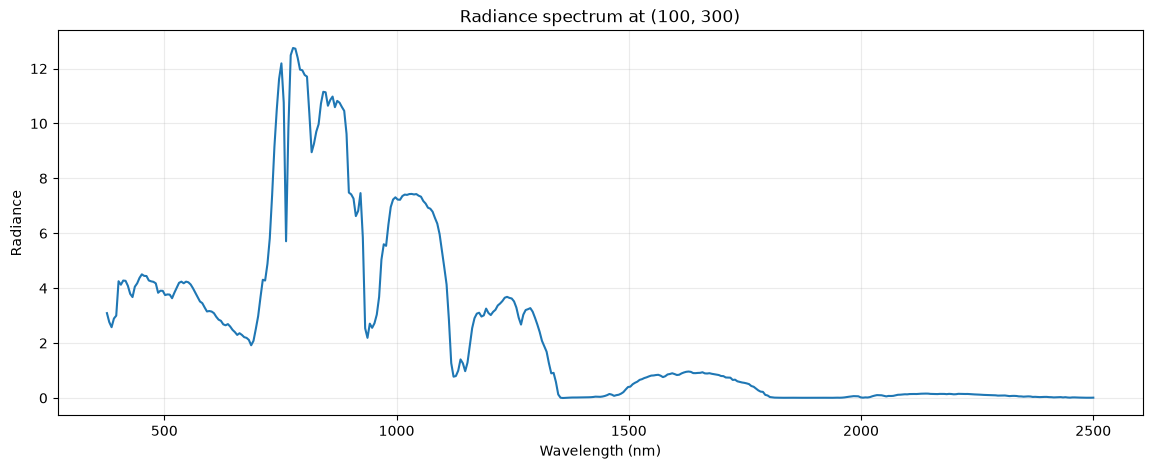

In [30]:
# ------------------------------------------------------------
# 2. Representative spectrum
# ------------------------------------------------------------
# Inspect one complete spectrum of a random pixel (100, 300): this IS the vector x_{r,c} from Section 02
# we cannot say that include the gas signature in the spectrum

random_row, random_col = 100, 300
spectrum = np.asarray(rdn_memmap[random_row, random_col, :], dtype=np.float32).squeeze()

print("Shape:", spectrum.shape, "Finite:", np.isfinite(spectrum).sum(), f"({np.isfinite(spectrum).sum() / len(spectrum) * 100:.1f}%)")

plt.figure(figsize=(14, 5))
plt.plot(wavelengths, spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title(f"Radiance spectrum at ({random_row}, {random_col})")
plt.grid(alpha=.25)
plt.show()

| おおよその波長範囲     | 主な吸収成分           | 主な起源                 |
| ------------- | ---------------- | -------------------- |
| 約400–700 nm   | 色素               | 植生、土壌、鉱物             |
| 約760 nm       | O₂               | 大気中の酸素               |
| 約900–1000 nm  | H₂O              | 水蒸気、大気および地表物質        |
| 約1200 nm      | H₂O              | 大気中の水蒸気、地表物質         |
| 約1400 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約1900 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約2000–2200 nm | H₂O + 鉱物         | 水、粘土鉱物、炭酸塩鉱物など       |
| 約2120–2485 nm | **CH₄ + その他の寄与** | CH₄検出・解析に利用するスペクトル領域 |


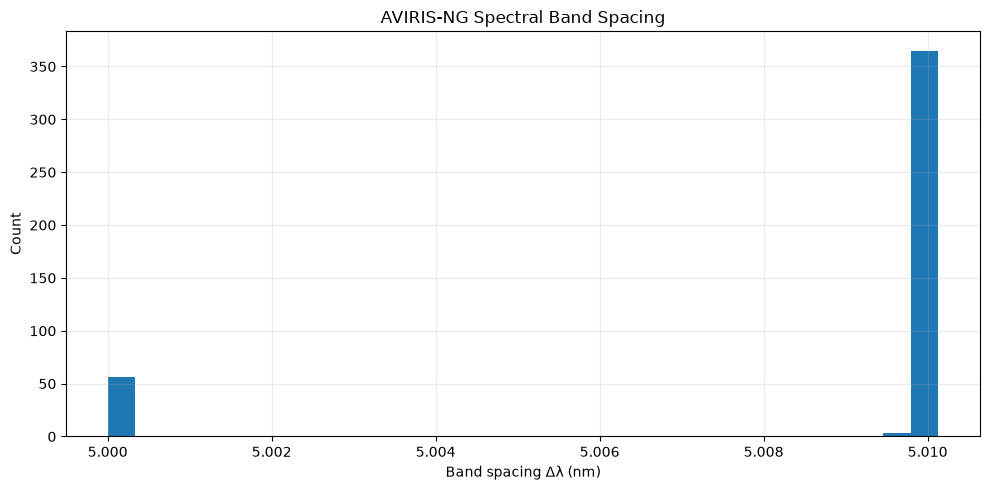

In [31]:
# ------------------------------------------------------------
# 3. Spectral band spacing - check the uniformity of the spectral sampling
# ------------------------------------------------------------

band_spacing = np.diff(wavelengths)

plt.figure(figsize=(10, 5))

plt.hist(
    band_spacing,
    bins=30
)

plt.xlabel("Band spacing Δλ (nm)")
plt.ylabel("Count")
plt.title("AVIRIS-NG Spectral Band Spacing")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 04. Radiance and wavelength calibration validation - 放射輝度と波長の校正の検証

The AVIRIS-NG radiance product is already instrument-calibrated. This notebook does not perform the radiometric calibration itself; it loads the calibrated radiance values supplied in the ENVI product.

The wavelength calibration is also provided by the ENVI header. The header contains the center wavelength corresponding to each spectral band, so wavelengths must be read from the metadata rather than inferred from the band index.

The code below therefore validates the calibration metadata by checking:

* that the number of wavelengths matches the number of spectral bands;
* that wavelengths are monotonically increasing;
* that the wavelength range is physically plausible;
* that an example radiance spectrum contains only finite values.

Because the instrument has a finite spectral response function, each measured spectral band represents a finite spectral interval rather than an infinitely narrow molecular line.

ハイパースペクトルデータでは、各バンドがどの波長に対応しているのかを正確に知る必要があります。そのため、波長をバンド番号から推定するのではなく、ENVIヘッダーに記録された校正済みの中心波長を使用します。

ここでは、放射輝度および波長の校正を新たに計算するのではなく、既に校正されたAVIRIS-NG製品を読み込み、ENVIメタデータに記録された校正情報の整合性を検証します。


In [32]:


print(
    "Header wavelengths are monotonically increasing:",
    np.all(np.diff(wavelengths) > 0)
)

print(
    "Header wavelength range (nm):",
    wavelengths.min(), "-", wavelengths.max()
)

print("These must NOT be treated as interchangeable.")

# Validate that every spectral band has one corresponding wavelength
check(
    "Wavelength count matches spectral bands",
    len(wavelengths) == rdn_memmap.shape[2],
    f"{len(wavelengths)} wavelengths vs {rdn_memmap.shape[2]} spectral bands"
)

# Validate that the wavelength range is physically plausible for AVIRIS-NG
check(
    "Wavelength range plausible",
    300 < wavelengths.min() < 500 and 2400 < wavelengths.max() < 2600,
    f"{wavelengths.min():.1f}-{wavelengths.max():.1f} nm"
)

# Validate that an example calibrated spectrum contains no NaN or Inf values
check(
    "Example spectrum fully finite",
    np.isfinite(spectrum).all(),
    f"{np.isfinite(spectrum).sum()}/{len(spectrum)}"
)

Header wavelengths are monotonically increasing: True
Header wavelength range (nm): 376.44 - 2500.12
These must NOT be treated as interchangeable.
[✓] Wavelength count matches spectral bands — 425 wavelengths vs 425 spectral bands
[✓] Wavelength range plausible — 376.4-2500.1 nm
[✓] Example spectrum fully finite — 425/425


True

## 05. CH₄ molecular absorption physics - メタン分子の吸収特性

Molecular transitions create characteristic absorption structures. Conceptually,

$$
R(\lambda)\approx C(\lambda)A_{CH4}(\lambda)+\epsilon(\lambda),
$$

where $C$ is broad background/continuum structure and $A_{CH4}$ is the methane absorption signature.

メタン（CH₄）分子は、特定の波長の電磁波を吸収します。
Methane (CH₄) molecules absorb electromagnetic radiation at specific wavelengths.

これは分子内部の振動・回転状態に対応する量子力学的な現象です。
This is a quantum mechanical phenomenon corresponding to the molecule's internal vibrational and rotational states.

したがって、CH₄が存在すると、その波長領域のスペクトルに特徴的な吸収構造が現れます。
Therefore, when CH₄ is present, characteristic absorption structures appear in the spectrum within that wavelength range.

本プロジェクトでは、特に
This project specifically analyzes the spectral region

$$ 2120\ \mathrm{nm} \leq \lambda \leq 2485\ \mathrm{nm} $$

のスペクトル領域を解析します。
within the above wavelength range.

この領域には、CH₄検出に利用できるスペクトル情報が含まれています。
This region contains spectral information that can be used for CH₄ detection.

ただし、センサーが測定するスペクトルは「純粋なCH₄のスペクトル」ではありません。
However, the spectrum measured by the sensor is not a "pure CH₄ spectrum."

実際の観測値には、
The actual observed values include:

地表面の反射特性
Surface reflectance characteristics
大気
Atmosphere
他の分子
Other molecules
太陽光
Sunlight
センサーの特性
Sensor characteristics
ノイズ
Noise

などが含まれます。
among other contributing factors.

したがって、CH₄の吸収信号を取り出すためには、背景スペクトルからCH₄に関連する変化を分離する必要があります。
Therefore, to extract the CH₄ absorption signal, it is necessary to separate the CH₄-related variations from the background spectrum.

[✓] CH4 spectral interval contains bands — 40 bands
Bands: 40 range: 2204.6 - 2399.94 nm


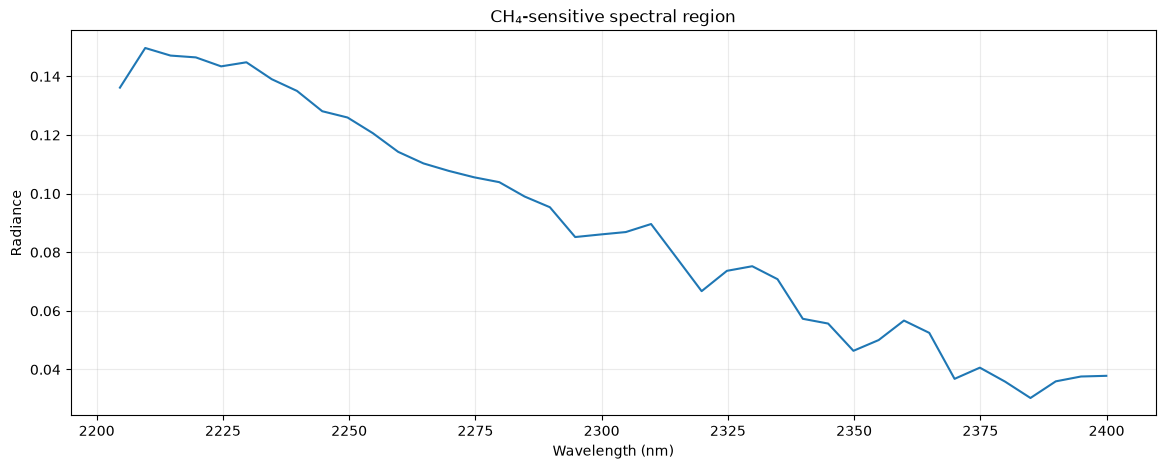

In [33]:
# CH4-sensitive spectral interval - include the full absorption window and some continuum on either side as shoulders

CH4_MIN, CH4_MAX = 2200.0, 2400.0

ch4_mask = (wavelengths >= CH4_MIN) & (wavelengths <= CH4_MAX)
ch4_indices = np.where(ch4_mask)[0]
ch4_wavelengths = wavelengths[ch4_mask]

check(
    "CH4 spectral interval contains bands",
    len(ch4_indices) > 0,
    f"{len(ch4_indices)} bands"
)

print(
    "Bands:", len(ch4_indices),
    "range:", ch4_wavelengths[0], "-", ch4_wavelengths[-1], "nm"
)

plt.figure(figsize=(14, 5))
plt.plot(ch4_wavelengths, spectrum[ch4_mask])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title("CH₄-sensitive spectral region")
plt.grid(alpha=.25)
plt.show()

In [34]:
check("CH4 wavelength range correct", ch4_wavelengths.min() >= CH4_MIN and ch4_wavelengths.max() <= CH4_MAX)

[✓] CH4 wavelength range correct


True

## 06. Beer–Lambert model 吸収式

The fundamental attenuation model for the observed radiance is

$$
I(\lambda)=I_0(\lambda)e^{-\tau(\lambda)}
$$

where $I(\lambda)$ is the observed radiance and $ I_0(\lambda)$ is the background/continuum radiance estimated in the absence of CH₄ absorption.

The optical depth is

$$
\tau(\lambda)=\sigma(\lambda)NL.
$$

Therefore,

$$
-\ln\left(\frac{I}{I_0}\right)=\tau.
$$

Remote-sensing methane retrievals are commonly expressed as concentration-path length, e.g. ppm·m, rather than simply ppm.

光が吸収性物質を通過すると、放射輝度は減少します。この現象はBeer–Lambertの法則によって表現できます。

ここで、

$I_0(\lambda)$：CH₄吸収がない場合の背景・連続スペクトル（continuum）の放射輝度

$I(\lambda)$：実際に観測された放射輝度

$\tau(\lambda)$：光学的厚さ（optical depth）

です。


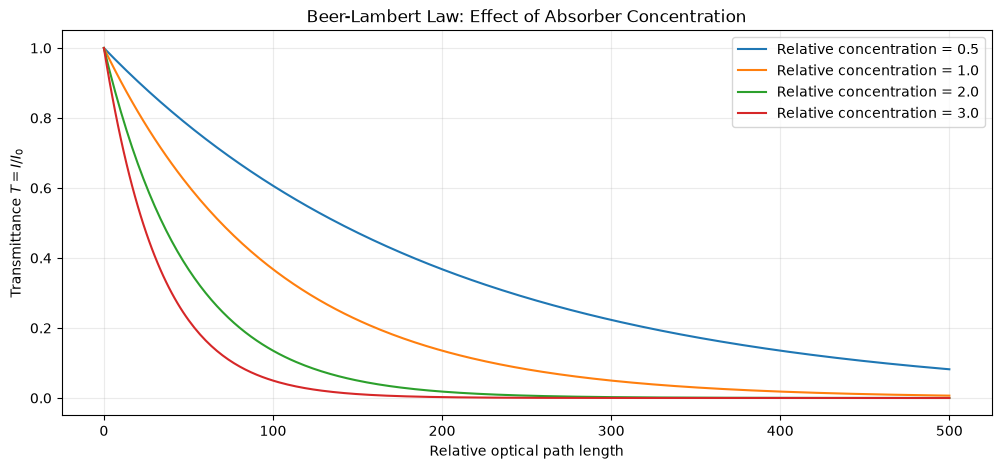

In [35]:
# --------------------------------------------------
# Synthetic Beer-Lambert demonstration
# --------------------------------------------------

# Relative optical path length
L = np.linspace(0, 500, 300)

# Relative absorber concentrations
concentrations = [0.5, 1.0, 2.0, 3.0]

# Arbitrary absorption coefficient
alpha = 0.01

plt.figure(figsize=(12, 5))

for C in concentrations:
    tau = alpha * C * L
    transmittance = np.exp(-tau)

    plt.plot(
        L,
        transmittance,
        label=f"Relative concentration = {C}"
    )

plt.xlabel("Relative optical path length")
plt.ylabel(r"Transmittance $T = I/I_0$")
plt.title("Beer-Lambert Law: Effect of Absorber Concentration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 07. Continuum Removal — Continuumの除去

A smooth continuum is estimated using a second-order polynomial fitted only to the shoulder bands outside the main CH₄ absorption region (2298–2358 nm).  
主なCH₄吸収帯（2298–2358 nm）を除いたショルダーバンドのみを使用し、2次多項式で滑らかなcontinuumを推定します。

$$
C(\lambda)=a_0+a_1\lambda+a_2\lambda^2
$$

The final spectrum is obtained by dividing by the estimated continuum.  
最終スペクトルは、推定したcontinuumで除算して求めます。

$$
X_p(\lambda)=\frac{X(\lambda)}{C(\lambda)}
$$

This removes the broad spectral shape while preserving the relative CH₄ absorption feature.  
これにより、広域的なスペクトル形状を除去し、CH₄吸収の相対的な特徴を保持します。

$$
\boxed{
\text{Radiance}
\rightarrow
\text{Continuum Removal}
\rightarrow
X_p
}
$$

``` text
shoulders:    |----------------|       |----------------|
                         2298        2358
                          CH4
```

In [36]:
# ============================================================
# Reading the CH4 image and constructing the reference map
# define absorption window for CH4
# separate filters and albedo factor
# ============================================================

# define absorption window for CH4 - without shoulders
CH4_ABS_MIN, CH4_ABS_MAX = 2298.0, 2358.0

# extract the dimensions of the reflectance memory map
n_lines, n_samples, n_bands = rdn_memmap.shape

# Open the CH4 image and construct the reference map 'ref'
ch4_img = open_image(str(CH4_HDR))

# load the CH4 image data into a numpy array, using memory mapping if available
open_memmap = getattr(ch4_img, "open_memmap", None)

if callable(open_memmap):
    ch4_array = np.asarray(open_memmap())
else:
    load = getattr(ch4_img, "load", None)
    if not callable(load):
        raise TypeError("The CH4 image object has neither open_memmap() nor load().")
    ch4_array = np.asarray(load())

# read band names from metadata (informativ, pastrat pentru print/log)
names = ch4_img.metadata.get("band names", [])
print("=== CH₄ Reference Image ===")
print(f"Shape : {ch4_array.shape}")
print(f"Dtype : {ch4_array.dtype}")
print(f"Bands : {len(names)}")
print(f"Band Names : {', '.join(names)}")



=== CH₄ Reference Image ===
Shape : (3987, 598, 5)
Dtype : float32
Bands : 5
Band Names : Red Radiance (uW nm-1 cm-2 sr-1), Green Radiance, Blue Radiance, Matched Filter Results (ppm m), Albedo Factor (dimensionless)


In [37]:
# create ref - as mach filter corrected
 
if isinstance(names, str):
    names = [names]

CH4_FILTER = 3  # "Matched Filter Results (ppm m)" — confirmat din band names
print(f"Identified CH4/matched-filter band: {CH4_FILTER} ({names[CH4_FILTER]})")

# Construct the reference CH4 map, replacing nodata values with NaN
ref = ch4_array[:, :, CH4_FILTER].astype(np.float32)
nodata_meta = ch4_img.metadata.get("data ignore value", None)
nodata_candidates = [float(nodata_meta)] if nodata_meta is not None else [-9999.0, -999.0, -32768.0]
for nodata in nodata_candidates:
    ref[ref == nodata] = np.nan

# create alb - albedo factor map, replacing nodata values with NaN
CH4_ALBEDO = 4  # "Albedo Factor" — confirmat din band names
print(f"Identified CH4/albedo band: {CH4_ALBEDO} ({names[CH4_ALBEDO]})")
# Albedo Factor - calculat o singura data aici, refolosit mai jos in vizualizare (Sec. RGB/MF/Albedo)
# si in filtrul de albedo din Sec.14 - nu se recalculeaza in alte celule
alb = np.array(ch4_array[:, :, CH4_ALBEDO], dtype=np.float32, copy=True)
for nodata in nodata_candidates:
    alb[alb == nodata] = np.nan

# --- 2. Sampling: toti pixelii finiti (fara eesantionare aleatoare) ---
rows_pca, cols_pca = np.where(np.isfinite(ref))
print(f"Esantion: {len(rows_pca)} pixeli (toti pixelii valizi din scena)")

Identified CH4/matched-filter band: 3 (Matched Filter Results (ppm m))
Identified CH4/albedo band: 4 (Albedo Factor (dimensionless))
Esantion: 2356120 pixeli (toti pixelii valizi din scena)


``` text
        z: bands (5)
        Red,Green,Blue,MF,Albedo
              ^
              |
        +-----------+
       /|          /|
      / |         / |
     +-----------+  |
     |  |        |  |--> y: samples (598)
     |  +--------|--+
     | /         | /
     |/          |/
     +-----------+
           |
           v
     x: lines (3987)

shape = (3987, 598, 5) = (x, y, z) = (lines, samples, bands)

x = lines (3987) — the sensor's flight direction (front-to-back, "along-track"). Each step along this axis is a new scan line, captured at a different moment in time as the aircraft moves forward.
y = samples (598) — the width of the scanned swath, perpendicular to the flight direction (left-right on the ground, "cross-track"). Fixed at 598, because the sensor has a fixed-width row of detectors — this number is a hardware property, not something that changes between flights.
z = bands (5) — not spatial at all; it's the "depth" of the cube. At every ground point (x, y), you have 5 different values stacked on top of each other (Red, Green, Blue, Matched Filter, Albedo) — think of it as 5 different channels of information for the same location, not 5 different places.
```


red: banda 55, wavelength reala = 651.9nm
green: banda 35, wavelength reala = 551.7nm
blue: banda 15, wavelength reala = 451.6nm


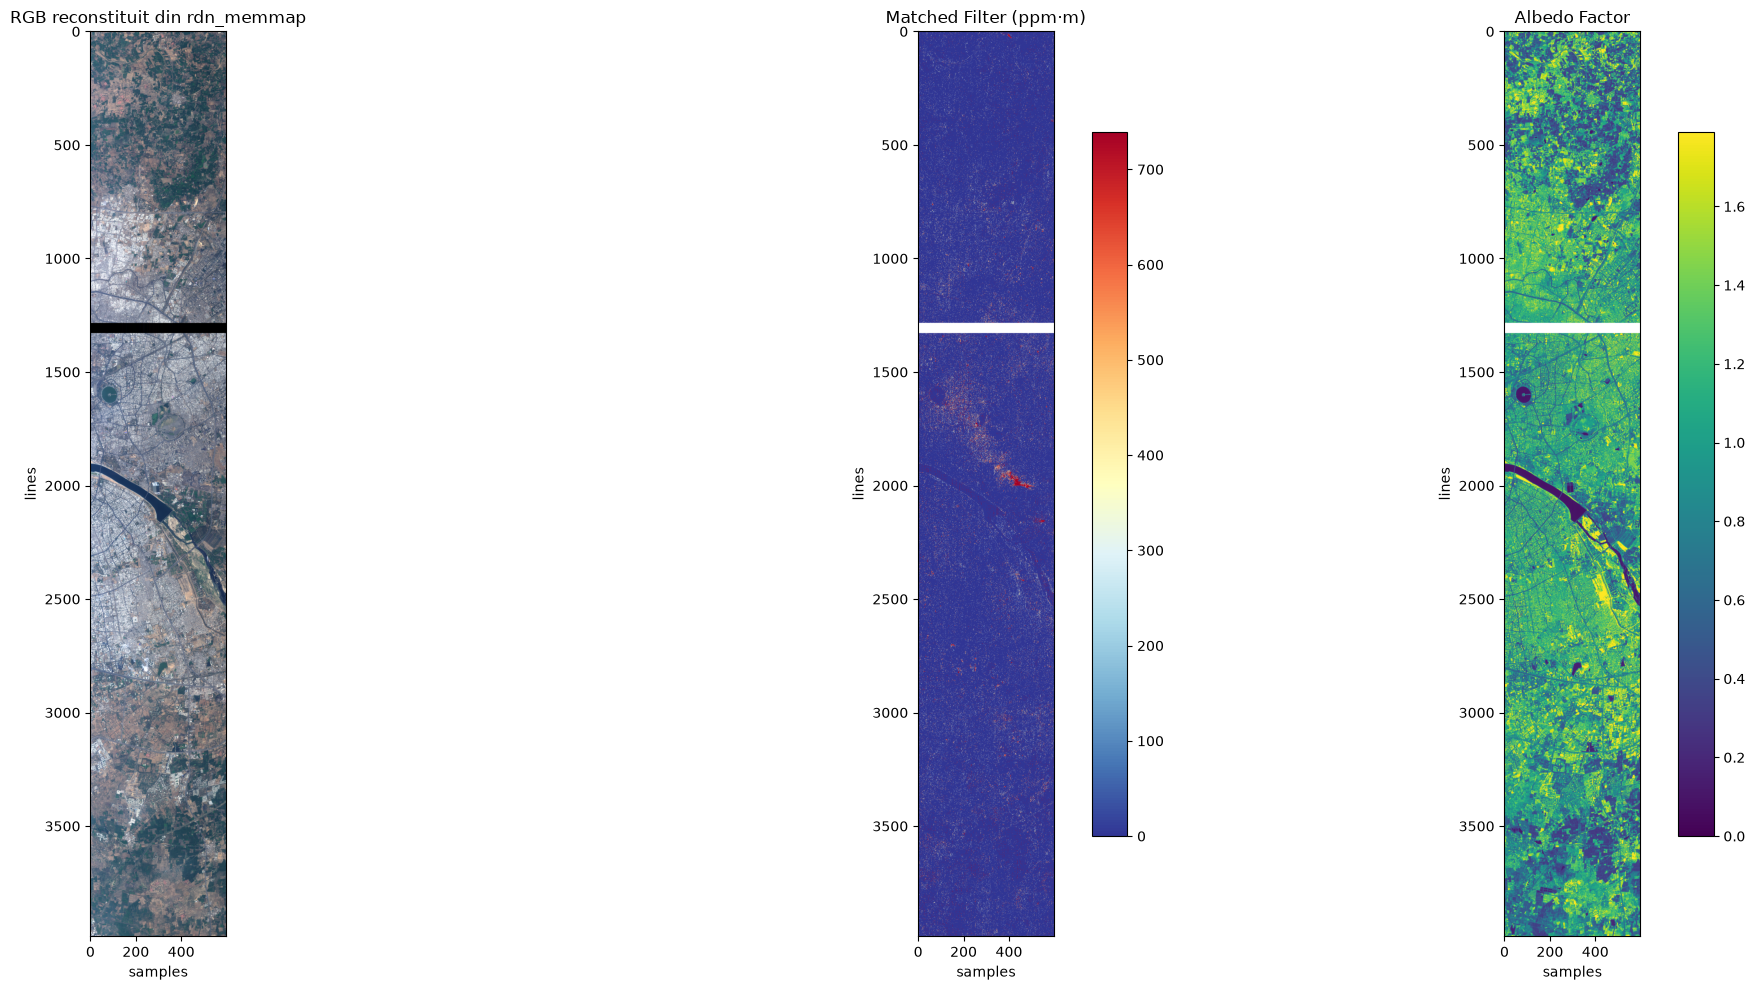

In [38]:
# ------------------------------------------------------------------------------
# Data visualization — Create a normalized version of a band for visualization
# ------------------------------------------------------------------------------
# Matplotlib.imshow cu date RGB float așteaptă valorile în intervalul [0, 1] (sau [0, 255] dacă sunt integers) — 
# dar red_full, green_full, blue_full sunt radianță brută, cu valori complet arbitrare (ar putea fi orice, de la 0 la sute sau mii, 
# în funcție de unități).

def normalize(band, pmin=1, pmax=99):
    lo, hi = np.nanpercentile(band, [pmin, pmax])
    out = np.clip((band - lo) / (hi - lo), 0, 1)
    return np.nan_to_num(out, nan=0.0)

# --- 1. Gaseste benzile din rdn_memmap cele mai apropiate de rosu/verde/albastru ---
target_wavelengths = {'red': 650, 'green': 550, 'blue': 450}  # nm, aproximativ

rgb_band_indices = {}
for color, target_nm in target_wavelengths.items():
    idx = np.argmin(np.abs(wavelengths - target_nm))
    rgb_band_indices[color] = idx
    print(f"{color}: banda {idx}, wavelength reala = {wavelengths[idx]:.1f}nm")

# --- 2. Extrage si copiaza (read-only fix) ---
red_full   = np.array(rdn_memmap[:, :, rgb_band_indices['red']],   dtype=np.float32, copy=True)
green_full = np.array(rdn_memmap[:, :, rgb_band_indices['green']], dtype=np.float32, copy=True)
blue_full  = np.array(rdn_memmap[:, :, rgb_band_indices['blue']],  dtype=np.float32, copy=True)

# nodata handling, la fel ca la 'ref'
for band in (red_full, green_full, blue_full):
    for nodata in nodata_candidates:
        band[band == nodata] = np.nan

# --- 3. Combina in RGB (ABIA ACUM, dupa ce benzile exista) ---
rgb_reconstructed = np.dstack([normalize(red_full), normalize(green_full), normalize(blue_full)])

# --- 4. Plot cele trei alaturi ---
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(rgb_reconstructed)
axes[0].set_title("RGB reconstituit din rdn_memmap")

vmax_mf = np.nanpercentile(ref, 99)
im1 = axes[1].imshow(ref, cmap='RdYlBu_r', vmin=0, vmax=vmax_mf)
axes[1].set_title("Matched Filter (ppm·m)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

vmax_alb = np.nanpercentile(alb, 98)
im2 = axes[2].imshow(alb, cmap='viridis', vmin=0, vmax=vmax_alb)
axes[2].set_title("Albedo Factor")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("samples"); ax.set_ylabel("lines")

plt.tight_layout()
plt.show()

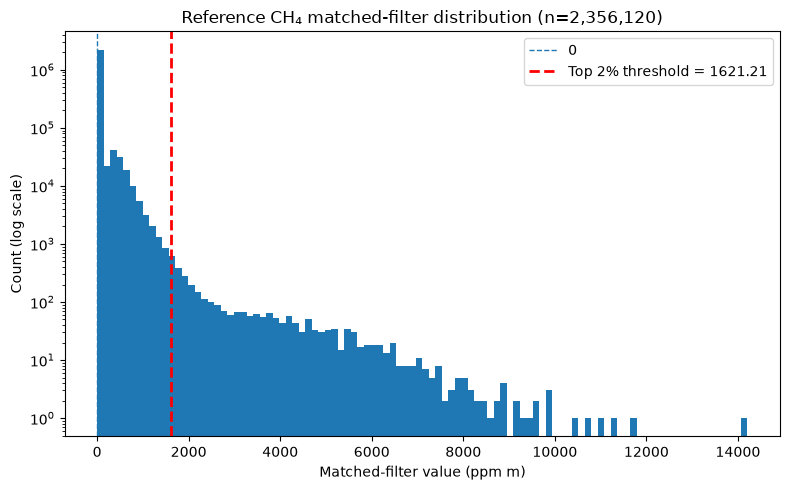

Threshold: 1621.2073
Background candidates: 2,353,276
Plume candidates: 2,844


In [39]:
# Distribution of positive reference CH4 values
ref_valid = ref[np.isfinite(ref)]
ref_pos = ref_valid[ref_valid > 0]

# Threshold corresponding to the top 2% of positive values
threshold = np.percentile(ref_pos, 98)

plt.figure(figsize=(8, 5))

plt.hist(ref_valid, bins=100)

# Zero reference
plt.axvline(
    0,
    linestyle='--',
    linewidth=1,
    label='0'
)

# Top-2% threshold
plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Top 2% threshold = {threshold:.2f}'
)

plt.yscale('log')

plt.title(f"Reference CH₄ matched-filter distribution (n={ref_valid.size:,})")
plt.xlabel("Matched-filter value (ppm m)")
plt.ylabel("Count (log scale)")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Threshold: {threshold:.4f}")
print(f"Background candidates: {(ref_valid < threshold).sum():,}")
print(f"Plume candidates: {(ref_valid >= threshold).sum():,}")

In [40]:
# ============================================================
# A. SAMPLING
# ============================================================
rows_all, cols_all = np.where(np.isfinite(ref))
print(f"Initial sample: {len(rows_all)} pixels")

# ============================================================
# B. INVALID PIXEL REMOVAL
# ============================================================
Xp = np.asarray(rdn_memmap[rows_all, cols_all][:, ch4_indices], dtype=np.float32)
finite_mask = np.isfinite(Xp).all(axis=1) & (Xp > 0).all(axis=1)

Xp = Xp[finite_mask]
rows_valid, cols_valid = rows_all[finite_mask], cols_all[finite_mask]
ref_valid = ref[rows_valid, cols_valid]

print(f"Valid pixels: {Xp.shape[0]:,} ({100*Xp.shape[0]/len(rows_all):.1f}%)")
check("Xp sampled pixels non-empty", Xp.shape[0] > 100, f"{Xp.shape[0]} pixels")
check("Xp fully finite and positive", np.isfinite(Xp).all() and (Xp > 0).all())

# ============================================================
# C. BACKGROUND ESTIMATION
# ============================================================
plume_candidate = np.isfinite(ref_valid) & (ref_valid >= threshold)
background_mask = ~plume_candidate  # is not plume
X_bg = Xp[background_mask]

print(f"Background: {X_bg.shape[0]:,} | Plume: {plume_candidate.sum():,}")
check("Background non-empty", X_bg.shape[0] > 100, f"{X_bg.shape[0]} pixels")

# ============================================================
# D. STATISTICAL BACKGROUND MODEL
# ============================================================
mu_bg = X_bg.mean(axis=0)
C_bg = np.cov(X_bg, rowvar=False).astype(np.float32)

print(f"mu_bg: {mu_bg.shape} | C_bg: {C_bg.shape}")
check("Background mean finite", np.isfinite(mu_bg).all())
check("Background covariance finite", np.isfinite(C_bg).all())

# ============================================================
# E. CONTINUUM REMOVAL
# ============================================================
shoulder_mask = ~(
    (ch4_wavelengths >= CH4_ABS_MIN) &
    (ch4_wavelengths <= CH4_ABS_MAX)
)
check("Shoulder mask covers most bands",
      shoulder_mask.sum() > 0.5 * len(ch4_wavelengths))

V_shoulder = np.column_stack([
    ch4_wavelengths[shoulder_mask]**2,
    ch4_wavelengths[shoulder_mask],
    np.ones(shoulder_mask.sum())
]).astype(np.float32)

V_all = np.column_stack([
    ch4_wavelengths**2,
    ch4_wavelengths,
    np.ones(len(ch4_wavelengths))
]).astype(np.float32)

continuum_operator = np.linalg.pinv(V_shoulder).astype(np.float32)
coeffs = Xp[:, shoulder_mask] @ continuum_operator.T
continuum = coeffs @ V_all.T
Xp_ratio = Xp / np.clip(continuum, 1e-6, None)

check("Xp_ratio finite everywhere", np.isfinite(Xp_ratio).all())
check("Xp_ratio centered near 1.0 on shoulders",
      abs(Xp_ratio[:, shoulder_mask].mean() - 1.0) < 0.05)
check("Xp_ratio dips inside CH4 window",
      Xp_ratio[:, ~shoulder_mask].mean() <= Xp_ratio[:, shoulder_mask].mean())

Initial sample: 2356120 pixels
Valid pixels: 2,356,120 (100.0%)
[✓] Xp sampled pixels non-empty — 2356120 pixels
[✓] Xp fully finite and positive
Background: 2,353,276 | Plume: 2,844
[✓] Background non-empty — 2353276 pixels
mu_bg: (40,) | C_bg: (40, 40)
[✓] Background mean finite
[✓] Background covariance finite
[✓] Shoulder mask covers most bands
[✓] Xp_ratio finite everywhere
[✓] Xp_ratio centered near 1.0 on shoulders
[✓] Xp_ratio dips inside CH4 window


True

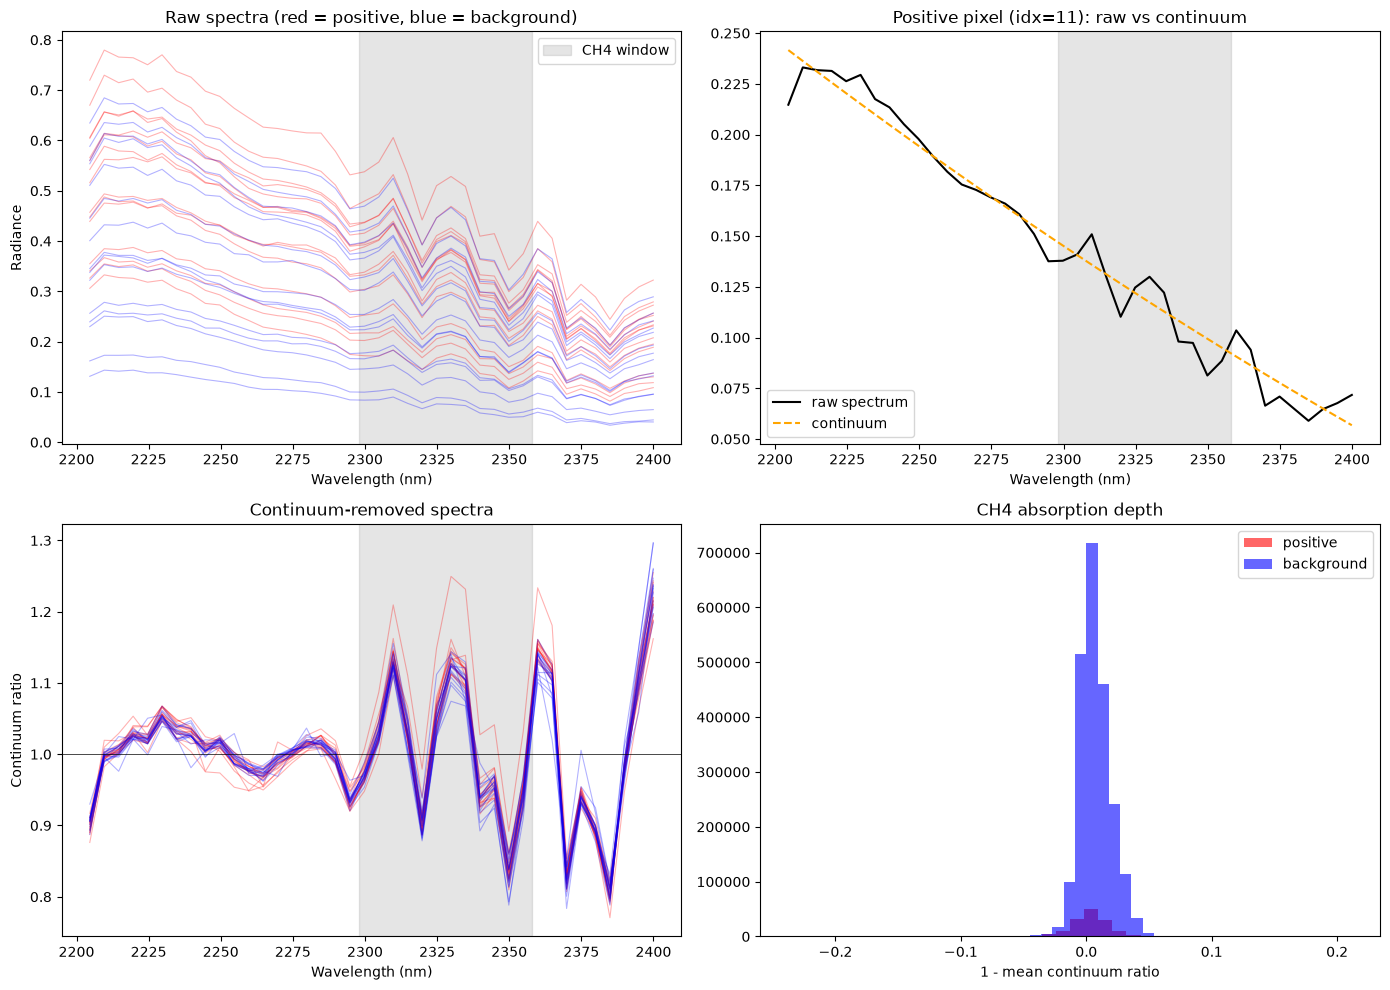

In [41]:
# Raw spectra — compares ref > 0 spectra with the background.
# Raw vs continuum — shows the spectral baseline and deviations from it.
# Continuum removed — removes the overall spectral shape to highlight CH₄ absorption.
# Absorption depth — checks whether ref > 0 pixels show stronger CH₄ absorption than the background.


is_pos = ref[rows_pca, cols_pca] > 0
plot_rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw spectra
ax = axes[0, 0]
idx_pos, idx_bg = np.where(is_pos)[0], np.where(~is_pos)[0]
for i in plot_rng.choice(idx_pos, min(15, len(idx_pos)), replace=False):
    ax.plot(ch4_wavelengths, Xp[i], color='red', alpha=0.3, lw=0.8)
for i in plot_rng.choice(idx_bg, min(15, len(idx_bg)), replace=False):
    ax.plot(ch4_wavelengths, Xp[i], color='blue', alpha=0.3, lw=0.8)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.2, label='CH4 window')
ax.set_title("Raw spectra (red = positive, blue = background)")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Radiance"); ax.legend()

# 2. Raw spectrum vs continuum
ax = axes[0, 1]
i0 = idx_pos[0]
ax.plot(ch4_wavelengths, Xp[i0], label='raw spectrum', color='black')
ax.plot(ch4_wavelengths, continuum[i0], label='continuum', color='orange', ls='--')
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.2)
ax.set_title(f"Positive pixel (idx={i0}): raw vs continuum")
ax.set_xlabel("Wavelength (nm)"); ax.legend()

# 3. Continuum-removed spectra
ax = axes[1, 0]
for i in plot_rng.choice(idx_pos, min(15, len(idx_pos)), replace=False):
    ax.plot(ch4_wavelengths, Xp_ratio[i], color='red', alpha=0.3, lw=0.8)
for i in plot_rng.choice(idx_bg, min(15, len(idx_bg)), replace=False):
    ax.plot(ch4_wavelengths, Xp_ratio[i], color='blue', alpha=0.3, lw=0.8)
ax.axhline(1.0, color='k', lw=0.5)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.2)
ax.set_title("Continuum-removed spectra")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Continuum ratio")

# 4. CH4 absorption depth
ax = axes[1, 1]
depth = 1.0 - Xp_ratio[:, ~shoulder_mask].mean(axis=1)
ax.hist(depth[is_pos], bins=40, alpha=0.6, color='red', label='positive')
ax.hist(depth[~is_pos], bins=40, alpha=0.6, color='blue', label='background')
ax.set_title("CH4 absorption depth")
ax.set_xlabel("1 - mean continuum ratio"); ax.legend()

plt.tight_layout()
plt.show()

## 08. Per-pixel absorption proxy - Demonstration - 画素ごとの吸収プロキシ（デモンストレーション）

For each sampled pixel, the continuum-normalized absorption proxy is

サンプリングした各画素について、連続スペクトル（continuum）で正規化した吸収プロキシを次式で定義する。

$$
A(\lambda)= -\ln\left( \frac{L(\lambda)}{C(\lambda)} \right).
$$

where $L(\lambda)$ is the measured radiance and $C(\lambda)$ is the estimated spectral continuum.

ここで、$L(\lambda)$ は観測放射輝度、$C(\lambda)$ は推定されたスペクトル連続成分（continuum）を表す。

For absorption,

吸収が生じている場合、

$$
L(\lambda) < C(\lambda) \quad\Rightarrow\quad A(\lambda) > 0.
$$

The absorption proxy is calculated for all valid pixels sampled in Section 07 (all finite pixels in the scene, not a fixed subset). One representative pixel is presented here for demonstration only.

この吸収プロキシは、Section 07で抽出したシーン内のすべての有効画素について計算される（固定数のサブセットではない）。ここでは、その計算方法を示すために代表的な1画素のみを例として可視化する。

The resulting $A(\lambda)$ is a **continuum-normalized absorption proxy**, not a direct CH4 concentration estimate.

得られた $A(\lambda)$ は**連続スペクトル正規化吸収プロキシ**であり、CH4 濃度を直接推定する値ではない。

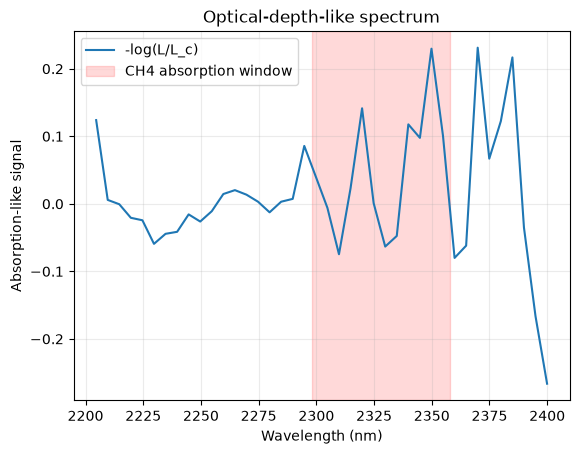

In [42]:

spec_ch4 = spectrum[ch4_mask].astype(float)

def polynomial_continuum_shoulder(ch4_wavelengths, y, shoulder_mask, degree=2):
    ok = np.isfinite(ch4_wavelengths) & np.isfinite(y) & shoulder_mask
    coeffs = np.polyfit(ch4_wavelengths[ok], y[ok], degree)
    return np.polyval(coeffs, ch4_wavelengths)

continuum = polynomial_continuum_shoulder(ch4_wavelengths, spec_ch4, shoulder_mask)

absorption = -np.log(np.clip(spec_ch4 / continuum, 1e-6, None))

plt.plot(ch4_wavelengths, absorption, label="-log(L/L_c)")
plt.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, alpha=0.15, color='red', label="CH4 absorption window")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Absorption-like signal")
plt.title("Optical-depth-like spectrum")
plt.legend(); plt.grid(alpha=.25); plt.show()

## 09. Fourier spectral analysis - Demonstration / フーリエスペクトル解析 => 実例

For a sampled spectrum $x_n$,

サンプリングされたスペクトル $x_n$ に対して、

$$
X_k=\sum_{n=0}^{N-1}x_ne^{-i2\pi kn/N}.
$$

We inspect $|X_k|$ to diagnose broad versus rapid spectral variations, noise and smoothing effects.

$|X_k|$ を調べることで、緩やかな変化と急激な変化、ノイズ、平滑化の影響を診断する。

**FFT is not used for CH4 retrieval.** CH4 absorption is a single localized dip (2298–2358 nm), not a periodic signal — FFT is built for detecting periodicities, not isolated shape features. Matched filtering and continuum removal (Sections 07–08, 12–13) compare the spectral *shape* directly in the wavelength domain, which is what actually characterizes molecular absorption. This section is demonstration only; no result feeds into later sections.

**FFTはCH4検出には使用しない。** CH4吸収は局在した単一の落ち込み（2298–2358nm）であり、周期信号ではない — FFTは周期性の検出に適した手法である。matched filterとcontinuum removal（セクション07–08、12–13）はスペクトルの**形状**を波長領域で直接比較するため、分子吸収の特徴づけに適している。本セクションはデモンストレーション目的のみで、結果は以降のセクションでは使用しない。

Note: band spacing is not perfectly uniform, so the frequency axis below uses the *median* spacing as a diagnostic approximation, not a calibrated axis.

注：バンド間隔は完全に均一ではないため、以下の周波数軸は*中央値*間隔による診断的近似であり、校正済みの軸ではない。

[✓] Wavelength grid approximately uniform for FFT — median Δλ=5.010010 nm, range=5.000000 - 5.010010 nm


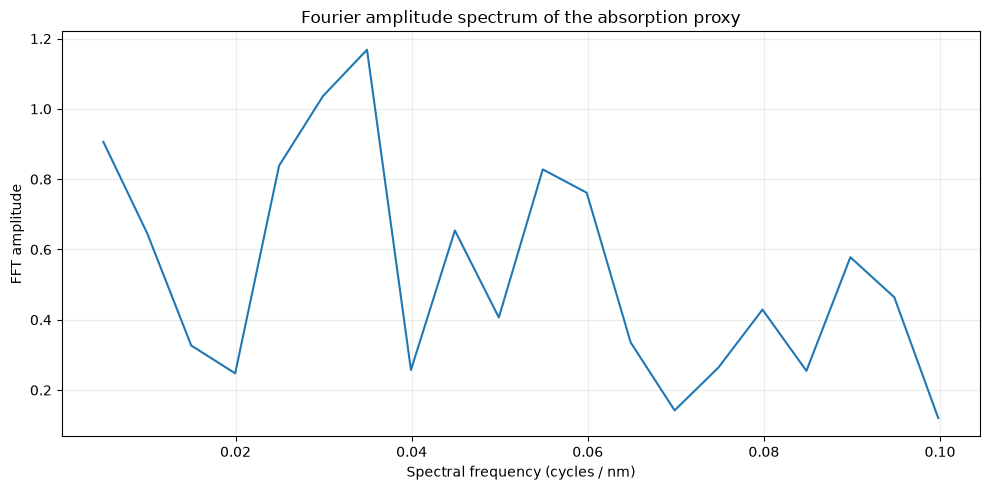

In [43]:
delta = np.diff(ch4_wavelengths)

check(
    "Wavelength grid approximately uniform for FFT",
    np.allclose(
        delta,
        np.median(delta),
        rtol=5e-3,
        atol=1e-6
    ),
    f"median Δλ={np.median(delta):.6f} nm, "
    f"range={delta.min():.6f} - {delta.max():.6f} nm"
)

# FFT requires an approximately uniformly sampled wavelength grid.
delta_lambda = float(np.median(np.diff(ch4_wavelengths)))

# Remove the DC component before computing the FFT.
signal = np.nan_to_num(absorption - np.nanmean(absorption))

fft_vals = np.fft.rfft(signal)

freq = np.fft.rfftfreq(
    len(signal),
    d=delta_lambda
)

amplitude = np.abs(fft_vals)

plt.figure(figsize=(10, 5))

plt.plot(freq[1:], amplitude[1:])

plt.title("Fourier amplitude spectrum of the absorption proxy")
plt.xlabel("Spectral frequency (cycles / nm)")
plt.ylabel("FFT amplitude")

plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 10. PCA / Covariance Analysis — All Sampled Spectra / 全サンプルスペクトル

PCA is applied to the sampled spectra to identify the dominant modes of spectral variability and redundancy.

PCAは、サンプルスペクトルに適用し、スペクトル変動の主要な成分と冗長性を調べる。

After centering, $X_c = X - \mu$, the covariance matrix is $C = \frac{1}{N-1}X_c^T X_c$, and PCA solves $Cv_i = \lambda_i v_i$. The eigenvectors $v_i$ represent the principal spectral directions, while $\lambda_i$ represents the variance of each component. PCA is used here as a **diagnostic tool**, not as a requirement for Random Forest.

中心化後（$X_c = X - \mu$）、共分散行列は $C = \frac{1}{N-1}X_c^T X_c$ であり、PCAは $Cv_i = \lambda_i v_i$ を解く。固有ベクトル $v_i$ は主要なスペクトル方向を、固有値 $\lambda_i$ は各成分の分散を表す。ここでのPCAは**診断・解析用**であり、Random Forestに必須ではない。

Two variants are compared below, to see how different preprocessing choices affect where spectral variance concentrates.

以下では、前処理の選択によってスペクトル分散の集中の仕方がどう変わるかを比較するため、2つのバリエーションを検討する。

### Modification 1 — Log-Radiance / 対数放射輝度

Under the multiplicative model $L(\lambda) \approx A\,S(\lambda)\,T(\lambda)$, the logarithm converts multiplicative factors into additive terms: $\ln L(\lambda) = \ln A + \ln S(\lambda) + \ln T(\lambda)$. This makes the broadband factors (albedo $A$, illumination/surface term $S$) easier to separate mathematically from the narrowband absorption term $T(\lambda)$ — but it does **not remove** albedo or illumination effects; it only changes how they combine with the rest of the signal.

乗算モデル $L(\lambda) \approx A\,S(\lambda)\,T(\lambda)$ のもと、対数変換は乗算的な要因を加算的な要因に変換する：$\ln L(\lambda) = \ln A + \ln S(\lambda) + \ln T(\lambda)$。これにより、広帯域要因（アルベド $A$、照明・地表項 $S$）と狭帯域の吸収項 $T(\lambda)$ を数学的に分離しやすくなるが、アルベドや照明の影響そのものは**除去されない**——これらが信号の他の要素とどう結合するかが変わるだけである。

### Modification 2 — Continuum Removal / Continuum除去

The local continuum $C(\lambda)$ is estimated from spectral regions outside the CH₄ absorption window. The continuum-normalized spectrum is $R(\lambda) = L(\lambda)/C(\lambda)$, and the corresponding absorption proxy is $A(\lambda) = -\ln(L(\lambda)/C(\lambda))$. Dividing by an estimated local baseline is a more targeted correction than the global log transform above: it explicitly removes the slowly-varying broadband shape local to each spectrum, leaving mainly the localized absorption structure. It still does not fully eliminate albedo, illumination, or atmospheric effects — it reduces their influence on the spectral *shape* within the absorption window, not their absolute magnitude.

CH₄吸収窓の外側の領域から局所的なcontinuum $C(\lambda)$ を推定する。正規化スペクトルは $R(\lambda) = L(\lambda)/C(\lambda)$、対応する吸収プロキシは $A(\lambda) = -\ln(L(\lambda)/C(\lambda))$ である。推定された局所ベースラインで除算することは、上記の対数変換よりも的を絞った補正であり、各スペクトルに固有の緩やかに変化する広帯域形状を明示的に除去し、主に局所的な吸収構造を残す。ただし、アルベド・照明・大気効果を完全に除去するわけではなく——吸収窓内でのスペクトルの**形状**への影響を低減するのであって、絶対的な大きさを低減するわけではない。



log-radiance
Explained variance: [0.87124306 0.06535011 0.02119866 0.00585298 0.0036454 ]
Cumulative: [0.87124306 0.9365932  0.95779186 0.96364486 0.9672903 ]
[✓] Explained variance sums to <= 1.0 (log-radiance)
[✓] Explained variance ratios monotonic decreasing (log-radiance)
[✓] PCA components orthonormal (log-radiance)


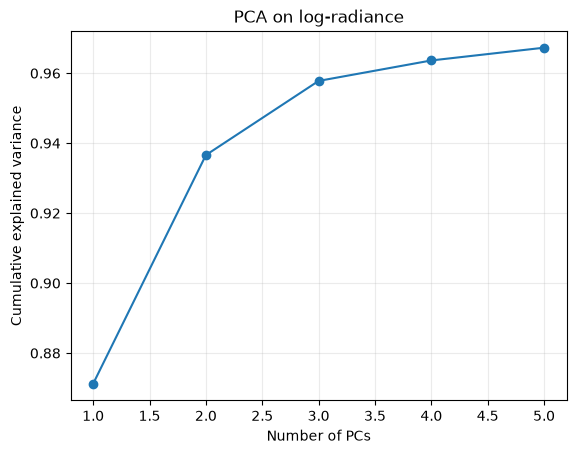


continuum-removed ratio
Explained variance: [9.8775816e-01 5.5633280e-03 1.4241225e-03 9.0887037e-04 4.2465856e-04]
Cumulative: [0.98775816 0.9933215  0.9947456  0.99565446 0.99607915]
[✓] Explained variance sums to <= 1.0 (continuum-removed ratio)
[✓] Explained variance ratios monotonic decreasing (continuum-removed ratio)
[✓] PCA components orthonormal (continuum-removed ratio)


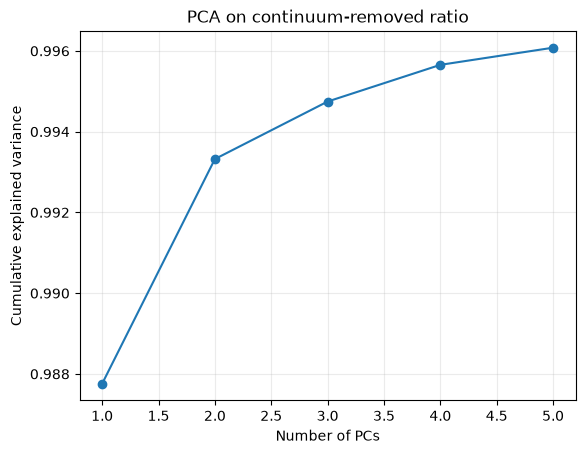

In [44]:
# --- Section 10: PCA - Diagnostics ---
# Reuses Xp and Xp_ratio calculated in Section 07 — no resampling from memmap.

PCA_RANDOM_STATE = 0  # PCA e deterministic pentru solver-ul implicit ('full'/'auto'),
                       # dar sklearn cere totusi un random_state pentru solver-ele randomized

def run_pca_diagnostics(X, label, n_components=5):
    n_components = min(n_components, X.shape[0], X.shape[1])
    pca = PCA(n_components=n_components, random_state=PCA_RANDOM_STATE)
    scores = pca.fit_transform(X)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    print(f"\n{label}")
    print("Explained variance:", pca.explained_variance_ratio_)
    print("Cumulative:", cumvar)

    check(f"Explained variance sums to <= 1.0 ({label})", cumvar[-1] <= 1.0 + 1e-6)
    check(f"Explained variance ratios monotonic decreasing ({label})",
          np.all(np.diff(pca.explained_variance_ratio_) <= 1e-9))
    check(f"PCA components orthonormal ({label})",
          np.allclose(pca.components_ @ pca.components_.T,
                       np.eye(pca.components_.shape[0]), atol=1e-4))

    plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
    plt.xlabel("Number of PCs")
    plt.ylabel("Cumulative explained variance")
    plt.title(f"PCA on {label}")
    plt.grid(alpha=.25)
    plt.show()

    return pca, scores

# Modification 1 — log-radiance
Xp_log = np.log(Xp)
Xp_log_centered = Xp_log - Xp_log.mean(axis=1, keepdims=True)
pca_log, scores_log = run_pca_diagnostics(Xp_log_centered, "log-radiance")

# Modification 2 — continuum-removed ratio
pca_ratio, scores_ratio = run_pca_diagnostics(Xp_ratio, "continuum-removed ratio")


### Interpreting the results / 結果の解釈

For each variant, PC1's share of explained variance indicates how concentrated the remaining variability is into a single dominant direction. A high PC1 on raw or log-radiance typically reflects broadband effects (albedo, illumination, viewing geometry) that vary together across most bands. After continuum removal, broadband variability has largely been divided out — so if PC1 is *higher* on the continuum-removed ratio than on log-radiance, it does not indicate a problem; it suggests the remaining, smaller-magnitude variability is now dominated by one correlated spectral structure (e.g. a shared absorption-like shape across sampled pixels), rather than by many independent broadband factors.



各バリエーションについて、PC1が説明する分散の割合は、残存する変動が単一の支配的な方向にどれだけ集中しているかを示す。Raw RadianceまたはLog-RadianceでPC1が高い場合、通常はほとんどのバンドで共通して変化する広帯域効果（アルベド、照明、観測幾何）を反映している。Continuum除去後は広帯域変動の大部分が取り除かれているため、continuum除去後のratioのPC1がlog-radianceより*高くなる*ことは問題を示すものではなく——残存する、より小さな変動が、多数の独立した広帯域要因ではなく、単一の相関したスペクトル構造（例えば、サンプリングされた画素間で共有される吸収様の形状）によって支配されていることを示唆する。



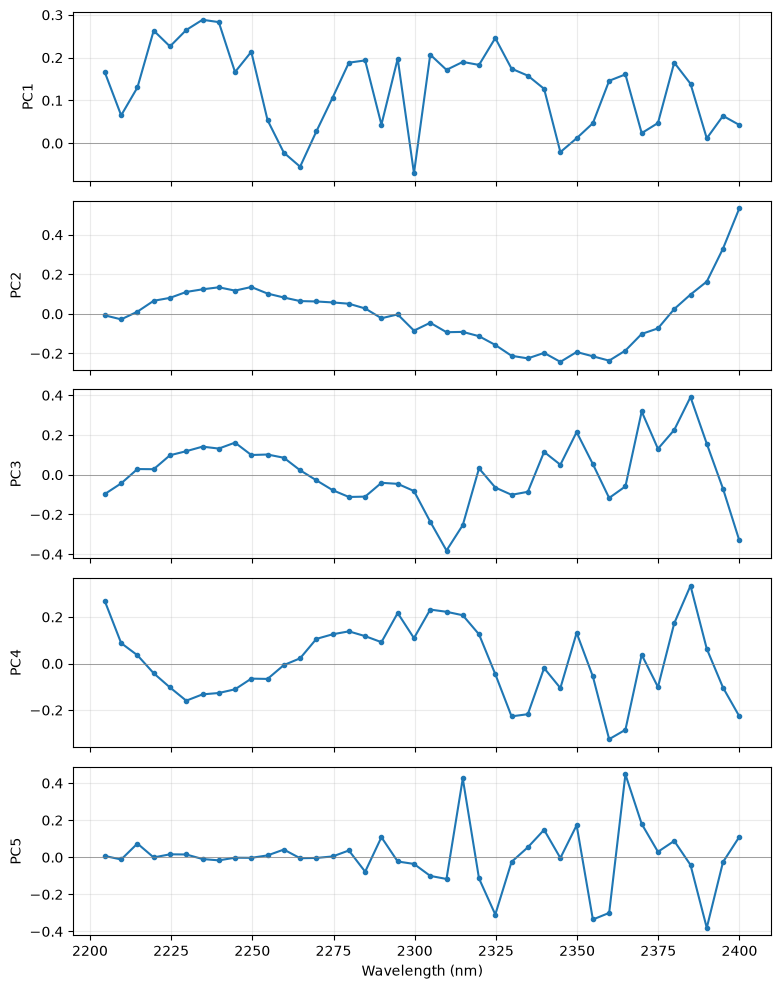

In [45]:
# continuum-removed ratio PCA components plotted against wavelengths in the CH4-sensitive region
wavelengths_ch4 = wavelengths[ch4_indices]

fig, axes = plt.subplots(
    len(pca_ratio.components_),
    1,
    figsize=(8, 2 * len(pca_ratio.components_)),
    sharex=True
)

for i, ax in enumerate(axes):
    ax.plot(wavelengths_ch4, pca_ratio.components_[i], marker=".")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel(f"PC{i+1}")
    ax.grid(alpha=.25)

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()

PC1 is monoton descending without pick, so appear so be albedo effect, so is needed a normalization or?

## 11. CH₄ Unit Absorption Spectrum & Spectral Similarity — CH₄ 単位吸収スペクトルとスペクトル類似度

The `*_ch4_ua.txt` file is treated as a **modeled CH₄ unit-absorption spectrum**, not as measured ground truth.

We extract its wavelength and absorption signal, verify wavelength overlap with AVIRIS-NG, and interpolate the reference spectrum onto the AVIRIS-NG wavelength grid. The resulting `UA_interpolated` provides a **CH₄ reference spectral signature** for comparison.

$$
\text{UA spectrum}
\;\rightarrow\;
\text{wavelength alignment}
\;\rightarrow\;
\boxed{\text{CH}_4\text{ reference UA_interpolated}}
$$

It is used for spectral comparison, not as an independent measurement of atmospheric CH₄ concentration.

**日本語**

`*_ch4_ua.txt` ファイルは、**モデル化された CH₄ の単位吸収スペクトル**として扱い、実測された ground truth とはみなしません。

波長と吸収信号を抽出し、AVIRIS-NG との波長範囲の重なりを確認した後、AVIRIS-NG の波長グリッドへ補間します。これにより、スペクトル比較に使用する **CH₄ の参照スペクトル `UA interpolated`** を作成します。

これは大気中 CH₄ 濃度の独立した実測値ではありません。

### Spectral similarity baseline

The measured spectrum \(x\) is compared with the CH₄ reference spectrum \(s\) using two simple baselines:

**Cosine similarity** measures overall spectral shape similarity.

$$
\cos\theta=
\frac{x^Ts}{\|x\|\|s\|}
$$

**Pearson correlation** measures similarity in the wavelength-by-wavelength variation pattern.

$$
\rho=
\frac{\sum_i(x_i-\bar{x})(s_i-\bar{s})}
{\sqrt{\sum_i(x_i-\bar{x})^2}
 \sqrt{\sum_i(s_i-\bar{s})^2}}
$$

These metrics provide **baseline spectral similarity scores** before applying more advanced retrieval or machine-learning methods.

**日本語**

測定スペクトル \(x\) と CH₄ 参照スペクトル \(s\) を、2つの基本的な指標で比較します。

* **コサイン類似度**：スペクトル全体の形状の類似性を評価する。
* **ピアソン相関係数**：波長に対する変化パターンの類似性を評価する。

これらは、高度な retrieval や機械学習を適用する前の **スペクトル類似度のベースライン**として使用します。


In [46]:
# --------------------------------------------------
# Load CH4 Unit Absorption (UA) reference spectrum
# --------------------------------------------------

# import the UA file, which contains the reference CH4 absorption spectrum
ua = np.loadtxt(UA_FILE)

if ua.ndim != 2 or ua.shape[1] < 3:
    raise ValueError(f"Unexpected UA file shape: {ua.shape}. Expected at least 3 columns.")

# columns: 0=index, 1=wavelength [nm], 2=UA signal
ua_wavelength = ua[:, 1].astype(np.float32)
ua_signal = ua[:, 2].astype(np.float32)

print(f"UA shape: {ua.shape}, wavelength: {ua_wavelength.min():.1f}-{ua_wavelength.max():.1f}nm, "
      f"signal std: {ua_signal.std():.4f}")

# check overlap with AVIRIS CH4 window
overlap_min = max(ua_wavelength.min(), ch4_wavelengths.min())
overlap_max = min(ua_wavelength.max(), ch4_wavelengths.max())
print(f"Overlap: {overlap_min:.1f}-{overlap_max:.1f}nm")

if overlap_min >= overlap_max:
    raise ValueError("No wavelength overlap between UA and AVIRIS.")

check("UA wavelengths strictly increasing", np.all(np.diff(ua_wavelength) > 0))

print("UA:", len(ua_wavelength))
print("AVIRIS:", len(wavelengths))

if len(ua_wavelength) == len(wavelengths):
    print("Same grid:", np.allclose(ua_wavelength, wavelengths, atol=1e-6))
    print("Max difference:", np.max(np.abs(ua_wavelength - wavelengths)))
else:
    print("Different grid sizes — interpolation required.")

# UA values interpolated onto AVIRIS wavelength grid
UA_interpolated = np.interp(ch4_wavelengths, ua_wavelength, ua_signal) 
print(f"Aligned target: min={UA_interpolated.min():.4f}, max={UA_interpolated.max():.4f}, std={UA_interpolated.std():.4f}")

if UA_interpolated.std() == 0:
    raise ValueError("Aligned CH4 UA_interpolatedis constant.")

UA shape: (212, 3), wavelength: 1443.3-2500.1nm, signal std: 0.2772
Overlap: 2204.6-2399.9nm
[✓] UA wavelengths strictly increasing
UA: 212
AVIRIS: 425
Different grid sizes — interpolation required.
Aligned target: min=-1.2483, max=-0.0992, std=0.2984


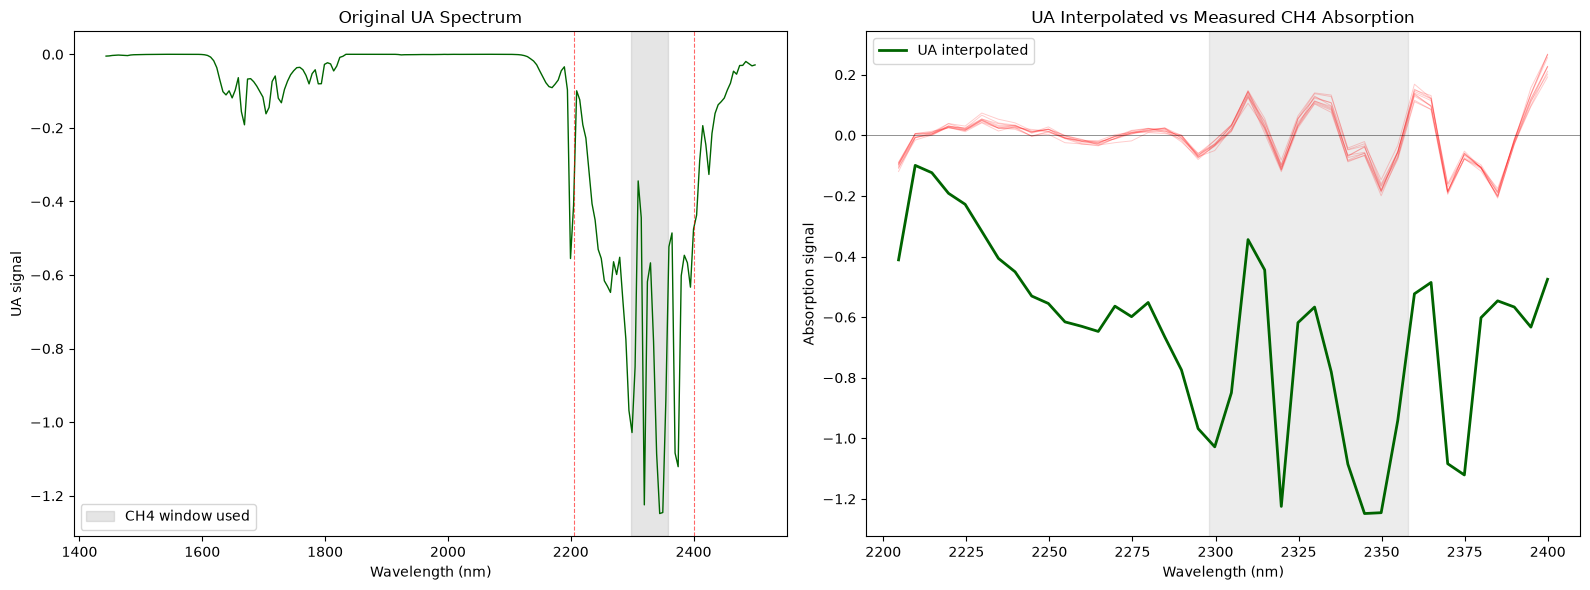

Overlap: 2204.6 - 2399.9 nm (100% of AVIRIS window)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Original UA spectrum
ax = axes[0]
ax.plot(ua_wavelength, ua_signal, color='darkgreen', lw=1)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.2, label='CH4 window used')
ax.axvline(overlap_min, color='red', ls='--', lw=0.8, alpha=0.6)
ax.axvline(overlap_max, color='red', ls='--', lw=0.8, alpha=0.6)
ax.set(title="Original UA Spectrum", xlabel="Wavelength (nm)", ylabel="UA signal")
ax.legend()

# 2. UA interpolated vs measured absorption
ax = axes[1]
ax.plot(ch4_wavelengths, UA_interpolated, color='darkgreen', lw=2, label='UA interpolated')

# Overlay measured continuum-removed spectra (absorption -> negative, same sign as UA)
if 'Xp_ratio' in dir():
    idx_pos_plot = np.where(ref[rows_pca, cols_pca] > 0)[0]
    if len(idx_pos_plot) > 0:
        plot_rng = np.random.default_rng(0)
        for i in plot_rng.choice(idx_pos_plot, min(10, len(idx_pos_plot)), replace=False):
            ax.plot(ch4_wavelengths, Xp_ratio[i] - 1, color='red', alpha=0.2, lw=0.7)

ax.axhline(0, color='black', lw=0.6, alpha=0.5)
ax.axvspan(CH4_ABS_MIN, CH4_ABS_MAX, color='gray', alpha=0.15)
ax.set(title="UA Interpolated vs Measured CH4 Absorption - zoom", xlabel="Wavelength (nm)", ylabel="Absorption signal")
ax.legend()

plt.tight_layout()
plt.show()

print(
    f"Overlap: {overlap_min:.1f} - {overlap_max:.1f} nm "
    f"({100 * (overlap_max - overlap_min) / (ch4_wavelengths.max() - ch4_wavelengths.min()):.0f}% "
    f"of AVIRIS window)"
)

In [48]:
print("UA Interpolated:")
print("  min =", UA_interpolated.min())
print("  max =", UA_interpolated.max())
print("  std =", UA_interpolated.std())
print("  norm =", np.linalg.norm(UA_interpolated))

print("wavelength:")
print("  min =", wavelengths.min())
print("  max =", wavelengths.max())
print("  n =", len(wavelengths))

UA Interpolated:
  min = -1.24830961227417
  max = -0.09921212494373322
  std = 0.2983909651628928
  norm = 4.486233701629294
wavelength:
  min = 376.44
  max = 2500.12
  n = 425


### UA Reference Spectrum

The UA file contains a **non-zero CH₄ reference spectral signature**.

- Wavelength range: **1443.29–2500.12 nm**
- Signal range: **−1.2483 to 0**
- AVIRIS overlap: **2204.6–2399.94 nm**
- The signal is interpolated onto the AVIRIS wavelength grid to create the `UA_interpolate` spectrum.

> The UA spectrum is the **CH₄ signature we are looking for**, not a CH₄ detection in the AVIRIS image.

### UA基準スペクトル

UAファイルには、**ゼロではないCH₄の基準スペクトル**が含まれています。

- 波長範囲: **1443.29–2500.12 nm**
- 信号範囲: **−1.2483～0**
- AVIRISとの重複範囲: **2204.6–2399.94 nm**
- AVIRISの波長グリッドに補間し、`UA_interpolate`スペクトルを作成します。

> UAスペクトルは**検出したCH₄ではなく、検出対象となるCH₄の基準スペクトル**です。

## 12. Matched-filter mathematics

A simplified matched-filter score is

$$
MF(x)=\frac{s^TC^{-1}x}{s^TC^{-1}s},
$$

where $s$ is the UA_interpolatedand $C$ is the background covariance.

**簡略化したmatched-filterスコアは次式で定義されます。**

$$
MF(x)=\frac{s^TC^{-1}x}{s^TC^{-1}s}
$$

ここで、$s$ はターゲットスペクトル、$C$ は背景スペクトルの共分散行列です。

The spectra are first converted to **log-radiance** and standardized band-by-band:

$$
X_{\log}=\ln(X),\qquad
X_z=\frac{X_{\log}-\mu_{\log}}{\sigma_{\log}}
$$

スペクトルはまず **log-radiance** に変換し、各波長バンドごとに標準化します。

$$
X_{\log}=\ln(X),\qquad
X_z=\frac{X_{\log}-\mu_{\log}}{\sigma_{\log}}
$$

The background covariance is then estimated in this standardized space, with a small ridge term added for numerical stability:

$$
C_{\mathrm{reg}}=C_{\mathrm{bg}}+\lambda I
$$

その後、この標準化空間で背景共分散行列を推定し、数値安定性を確保するため小さなridge項を追加します。

$$
C_{\mathrm{reg}}=C_{\mathrm{bg}}+\lambda I
$$

The CH₄ UA_interpolatedis standardized using the same background statistics:

$$
s_z=\frac{s}{\sigma_{\log}}
$$

CH₄ターゲットも、同じ背景統計量を用いて標準化します。

$$
s_z=\frac{s}{\sigma_{\log}}
$$

The measured spectrum is then scored as:

$$
MF(x)=
\frac{s_z^TC_{\mathrm{reg}}^{-1}x_z}
{s_z^TC_{\mathrm{reg}}^{-1}s_z}.
$$

測定スペクトルに対するMFスコアは次式で計算します。

$$
MF(x)=
\frac{s_z^TC_{\mathrm{reg}}^{-1}x_z}
{s_z^TC_{\mathrm{reg}}^{-1}s_z}.
$$

**Interpretation / 解釈**

- **High MF score / 高いMFスコア** → stronger compatibility with the CH₄ signature / CH₄特徴との適合性が高い
- **Low MF score / 低いMFスコア** → weaker compatibility / 適合性が低い
- **Negative MF score / 負のMFスコア** → variation opposite to the expected CH₄ signature / CH₄特徴とは逆方向の変化

Matched-filter denominator (s^T C^-1 s): 5054.781286471789
Matched-filter score for the example pixel: -0.0038495256578545177
Finite scores: 500/500


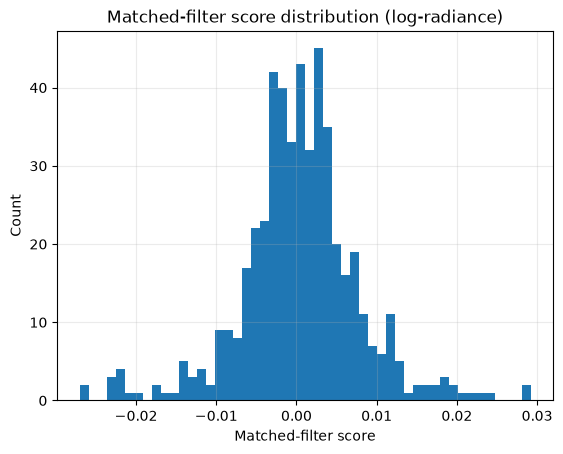

In [ ]:
if UA_interpolated is not None:
    # Calculate the mean spectrum and standard deviation for each wavelength
    Xp_mean = Xp_log.mean(axis=0)
    Xp_std = Xp_log.std(axis=0)

    # Avoid division by zero for bands with zero variance
    Xp_std_safe = np.where(Xp_std > 0, Xp_std, 1.0)

    # Standardize the background spectra band-by-band (Z-score)
    Xp_z = (Xp_log - Xp_mean) / Xp_std_safe

    # Estimate spectral covariance of the background
    C_bg = np.cov(Xp_z, rowvar=False)

    # Add a small ridge term to improve numerical stability
    ridge = 1e-3 * np.trace(C_bg) / C_bg.shape[0]
    C_bg_reg = C_bg + ridge * np.eye(C_bg.shape[0])

    # Check that the regularized covariance contains only finite values
    assert np.isfinite(C_bg_reg).all(), \
        "Background covariance has non-finite entries; check Xp for sensor fill values."

    # Compute the pseudoinverse of the background covariance matrix
    C_inv = np.linalg.pinv(C_bg_reg)

    # Check that the covariance inverse is numerically valid
    assert np.isfinite(C_inv).all(), \
        "Covariance inverse is non-finite; background sample is too ill-conditioned even after regularization."

    # Standardize the CH4 reference spectrum using the same background statistics
    s = UA_interpolated  / Xp_std_safe

    # Matched-filter normalization term: s^T C^-1 s
    denom = float(s @ C_inv @ s)
    print("Matched-filter denominator (s^T C^-1 s):", denom)

    if not np.isfinite(denom) or abs(denom) < 1e-12:
        # Skip scoring if the UA interpolated is degenerate or numerically unstable
        print("Matched-filter denominator is degenerate (near zero / non-finite); skipping scoring.")

    else:
        def matched_filter_score(x_log):
            # Standardize the measured spectrum using the background statistics
            xz = (x_log - Xp_mean) / Xp_std_safe

            # Compute the normalized matched-filter score
            return float(s @ C_inv @ xz) / denom

        # Convert the example radiance spectrum to log-radiance
        spec_ch4_log = np.log(np.clip(spec_ch4, 1e-3, None))

        # Calculate the matched-filter score for the example pixel
        mf_example = matched_filter_score(spec_ch4_log)
        print("Matched-filter score for the example pixel:", mf_example)

        # Calculate matched-filter scores for up to 500 background pixels
        mf_scores = np.array([
            matched_filter_score(Xp_log[i])
            for i in range(min(500, len(Xp_log)))
        ])

        # Keep only finite scores for the histogram
        finite_scores = mf_scores[np.isfinite(mf_scores)]
        print(f"Finite scores: {len(finite_scores)}/{len(mf_scores)}")

        if len(finite_scores) == 0:
            # Skip visualization if no valid scores were produced
            print("All matched-filter scores were non-finite; skipping histogram.")

        else:
            # Visualize the distribution of matched-filter scores
            plt.hist(finite_scores, bins=50)
            plt.xlabel("Matched-filter score")
            plt.ylabel("Count")
            plt.title("Matched-filter score distribution (log-radiance)")
            plt.grid(alpha=.25)
            plt.show()

else:
    # No CH4 reference spectrum is available, so matched filtering cannot be performed
    print("Skipping matched filter: no aligned CH4 UA_interpolated available.")

In [50]:
print("\n=== Matched-filter results ===")

print(f"Denominator: {denom:.6e}")
print(f"Example pixel MF score: {mf_example:.6f}")
print(f"Finite background scores: {len(finite_scores)}/{len(mf_scores)}")

print(f"Background MF mean: {np.mean(finite_scores):.6f}")
print(f"Background MF std:  {np.std(finite_scores):.6f}")
print(f"Background MF min:  {np.min(finite_scores):.6f}")
print(f"Background MF max:  {np.max(finite_scores):.6f}")

p95 = np.percentile(finite_scores, 95)
p99 = np.percentile(finite_scores, 99)

print(f"Background MF 95th percentile: {p95:.6f}")
print(f"Background MF 99th percentile: {p99:.6f}")
print(f"Example / background 99th percentile: {mf_example > p99}")


=== Matched-filter results ===
Denominator: 5.054781e+03
Example pixel MF score: -0.003850
Finite background scores: 500/500
Background MF mean: 0.000408
Background MF std:  0.007460
Background MF min:  -0.027023
Background MF max:  0.029192
Background MF 95th percentile: 0.011727
Background MF 99th percentile: 0.020550
Example / background 99th percentile: False


## 14. ML dataset construction / MLデータセットの構築

For sampled pixels,

サンプリングされた画素について、

$$
X_i=[R_i(\lambda_1),...,R_i(\lambda_B)],\quad y_i=CH4_i.
$$

For a baseline classifier we use

ベースライン分類器では、次式を用いる：

$$
y_i^{class}=1[y_i\ge Q_{0.98}(y)].
$$

This is a scene-relative **pseudo-label**, not a universal physical plume threshold.

これはシーン内相対的な**擬似ラベル（pseudo-label）**であり、普遍的な物理的プルーム閾値ではない。

Pixels with extreme albedo (top/bottom 2%) are excluded before sampling, since very dark or very bright surfaces are a known source of false positives in matched-filter retrievals.

アルベドが極端な値（上位・下位2%）を持つ画素は、サンプリング前に除外する。これは、非常に暗い、または非常に明るい地表面がmatched filter retrievalにおける既知の偽陽性の原因であるためである。

In [51]:
# データ　準備
"""
X = Xp_ratio
    → spectrele AVIRIS deja procesate în Sec. 07
    → continuum-normalized L/C
    → datele de intrare pentru ML

y = ref
    → valorile CH₄ / Matched Filter din fișierul CH₄ extern
    → valoarea-țintă asociată fiecărui pixel
"""

rows = rows_pca
cols = cols_pca

y = ref[rows, cols].astype(np.float32)

valid_y = np.isfinite(y)
for nodata in nodata_candidates:
    valid_y &= (y != nodata)

X = Xp_ratio[valid_y]
y = y[valid_y]
rows = rows[valid_y]
cols = cols[valid_y]

check("X has no NaN/Inf after reuse from Sec.07", np.isfinite(X).all())

# --- Filtru albedo: elimina pixeli cu reflectivitate extrema (surse cunoscute de fals-pozitive) ---
alb = np.array(ch4_array[:, :, 4], dtype=np.float32, copy=True)
for nodata in nodata_candidates:
    alb[alb == nodata] = np.nan

alb_lo, alb_hi = np.nanpercentile(alb, [2, 98])
albedo_ok = np.isfinite(alb) & (alb >= alb_lo) & (alb <= alb_hi)

valid_albedo = albedo_ok[rows, cols]
n_pos_before = int((y > 0).sum())

print(f"Pixeli eliminati de filtrul albedo: {(~valid_albedo).sum()} "
      f"({100*(~valid_albedo).mean():.1f}% din esantionul curent)")

X = X[valid_albedo]
y = y[valid_albedo]
rows = rows[valid_albedo]
cols = cols[valid_albedo]

n_pos_after = int((y > 0).sum())
print(f"Pozitivi (y>0): {n_pos_before} -> {n_pos_after} dupa filtrul albedo")

check("Dataset non-empty after albedo filter", len(y) > 100, f"{len(y)} pixeli ramasi")
check("X has no NaN/Inf after albedo filter", np.isfinite(X).all())

# Final ML/retrieval dataset:
#     X -> continuum-normalized CH4-region spectrum
#     y -> corresponding reference matched-filter value
print("X (continuum-normalized):", X.shape)
print("y:", y.shape)

print(
    pd.Series(y).describe(
        percentiles=[.5, .9, .95, .98, .99, .995]
    )
)

[✓] X has no NaN/Inf after reuse from Sec.07
Pixeli eliminati de filtrul albedo: 94245 (4.0% din esantionul curent)
Pozitivi (y>0): 142190 -> 132445 dupa filtrul albedo
[✓] Dataset non-empty after albedo filter — 2261875 pixeli ramasi
[✓] X has no NaN/Inf after albedo filter
X (continuum-normalized): (2261875, 40)
y: (2261875,)
count    2.261875e+06
mean     3.063880e+01
std      1.428793e+02
min      0.000000e+00
50%      0.000000e+00
90%      0.000000e+00
95%      2.778832e+02
98%      5.518376e+02
99%      7.276310e+02
99.5%    9.169979e+02
max      1.076626e+04
dtype: float64


In [52]:
# Check the distribution of the reference CH₄ values.
# This shows how many pixels have no detected CH₄ signal (y = 0)
# versus positive CH₄ retrieval values.

print("Zero values:", np.sum(y == 0))
print("Zero fraction:", np.mean(y == 0))

print("Positive values:", np.sum(y > 0))
print("Positive fraction:", np.mean(y > 0))


# Overall distribution of the reference CH₄ retrieval.
print("Quantiles:")

for q in [0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995]:
    print(f"Q{q:.3f} =", np.quantile(y, q))


# Analyze only pixels with a positive CH₄ retrieval.
# This helps characterize the magnitude of the detected CH₄ signal
# independently of the large zero-background population.
positive_y = y[y > 0]

print("Positive samples:", len(positive_y))

for q in [0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"Positive Q{q:.2f}:", np.quantile(positive_y, q))

Zero values: 2129430
Zero fraction: 0.9414445979552363
Positive values: 132445
Positive fraction: 0.05855540204476375
Quantiles:
Q0.500 = 0.0
Q0.750 = 0.0
Q0.900 = 0.0
Q0.950 = 277.88293
Q0.980 = 551.8375
Q0.990 = 727.6309
Q0.995 = 917.00616
Positive samples: 132445
Positive Q0.50: 453.63586
Positive Q0.75: 630.7013
Positive Q0.90: 872.4007
Positive Q0.95: 1083.1206
Positive Q0.99: 1625.0826


Așadar, produsul este puternic zero-inflated.　și aproape 100% dintre pixeli devin clasa 1.


Asta nu este o clasificare utilă.

Ce trebuie făcut

Pentru un pseudo-label bazat pe quantile, quantila trebuie aleasă în regiunea valorilor pozitive, nu în distribuția care are 94% zerouri.

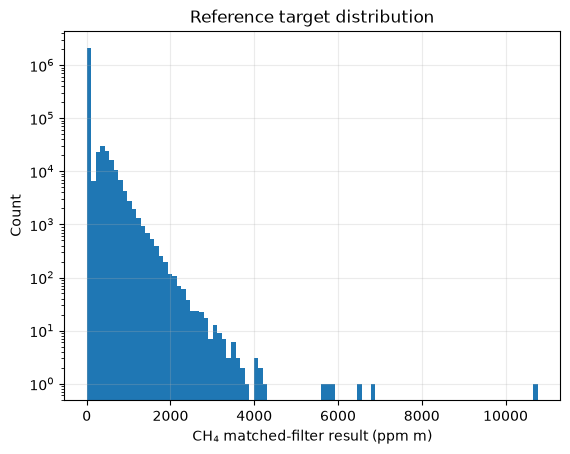

In [ ]:
# looks like the chap7 histogram but for this time only on metan spectrum"

plt.hist(y, bins=100)

plt.xlabel("CH₄ matched-filter result (ppm m)")
plt.ylabel("Count")
plt.title("Reference UA=interpolated distribution")
plt.yscale('log')
plt.grid(alpha=.25)
plt.show()


In [54]:
check(
    "X has no NaN/Inf",
    np.isfinite(X).all()
)

check(
    "y has no NaN/Inf",
    np.isfinite(y).all()
)



[✓] X has no NaN/Inf
[✓] y has no NaN/Inf


True

## 15. Spatial validation - train / test split

Hyperspectral pixels are spatially correlated. Random pixel splitting can leak neighboring information between train and test.

This section is placed **before** model training on purpose — in the previous version of this notebook it was numbered after classification and regression even though the split has to exist before either model can be fit.

As a baseline we split by image rows, with an explicit **buffer zone** of excluded rows around the split line to reduce leakage from spatial autocorrelation at the boundary:

$$
train:r<Q_{0.80}(r)-g,\qquad test:r\ge Q_{0.80}(r)+g,
$$

where $g$ is a small row gap. For publication-grade validation, multiple spatial blocks or spatial cross-validation should still be added.

row →
────────────────────────────────────────────────────────

       TRAIN          BUFFER          TEST
       <──────>       20 rows        <──────>
                    excluded
             │                    │
             │     row_cut        │
             │         ↓           │
─────────────┼────────────────────┼────────────────────
        row_cut-20              row_cut+20

In [55]:
SPATIAL_SPLIT_QUANTILE = 0.80
SPATIAL_BUFFER_ROWS = 20
PLUME_QUANTILE = 0.90

row_cut = np.quantile(rows, SPATIAL_SPLIT_QUANTILE)
train_mask = rows < row_cut - SPATIAL_BUFFER_ROWS
test_mask  = rows >= row_cut + SPATIAL_BUFFER_ROWS

X_train, X_test = X[train_mask], X[test_mask]
y_train_reg, y_test_reg = y[train_mask], y[test_mask]

check(
    "No row overlap between train and test",
    rows[train_mask].max() < rows[test_mask].min(),
    f"train max row={rows[train_mask].max()}, test min row={rows[test_mask].min()}"
)

# --- Threshold derivat DOAR din train (elimina leakage-ul din Sec.14 original) ---
positive_y_train = y_train_reg[y_train_reg > 0]
check("Train partition has positive retrieval values", len(positive_y_train) > 0,
      f"{len(positive_y_train)} positive samples in train")

threshold = float(np.quantile(positive_y_train, PLUME_QUANTILE))
print(f"Pseudo-label threshold (derivat DOAR din train): {threshold:.4f}")

y_train_cls = (y_train_reg >= threshold).astype(np.uint8)
y_test_cls  = (y_test_reg  >= threshold).astype(np.uint8)

print("Positive rate — train:", y_train_cls.mean())
print("Positive rate — test :", y_test_cls.mean())

if y_train_cls.sum() == 0 or y_test_cls.sum() == 0:
    raise ValueError(
        "Spatial split has no positive labels in one partition. "
        "Adjust SPATIAL_SPLIT_QUANTILE, SPATIAL_BUFFER_ROWS or PLUME_QUANTILE."
    )

check("Both partitions have positive labels",
      y_train_cls.sum() > 0 and y_test_cls.sum() > 0,
      f"train_pos={y_train_cls.sum()}, test_pos={y_test_cls.sum()}")

# y_class complet, folosit mai tarziu in Sec.22b pentru comparatia full-scene
y_class = (y >= threshold).astype(np.uint8)

expected_count_train = int(np.ceil((1.0 - PLUME_QUANTILE) * len(positive_y_train)))
tolerance_train = max(2, int(0.01 * len(positive_y_train)))
check(
    "Positive labels in train approx match positive-only quantile",
    abs(int(y_train_cls.sum()) - expected_count_train) <= tolerance_train,
    f"got {y_train_cls.sum()}, expected ≈{expected_count_train} (±{tolerance_train})"
)


[✓] No row overlap between train and test — train max row=3189, test min row=3230
[✓] Train partition has positive retrieval values — 106996 positive samples in train
Pseudo-label threshold (derivat DOAR din train): 839.6423
Positive rate — train: 0.005952188903562302
Positive rate — test : 0.009116293418076982
[✓] Both partitions have positive labels — train_pos=10700, test_pos=4019
[✓] Positive labels in train approx match positive-only quantile — got 10700, expected ≈10700 (±1069)


True

```
text
                Spectru
                   │
          ┌────────┴────────┐
          ↓                 ↓
   CLASSIFICATION       REGRESSION
          │                 │
   CH₄ ridicat?        Cât de mare?
      0 / 1             ppm·m
```

Total pixeli esantionati (y valid): 2261875
Pozitivi in tot esantionul (y>0): 132445
Pozitivi in train: 106996
Pozitivi cu eticheta 1 in train: 10700
Pozitivi cu eticheta 1 in test: 4019


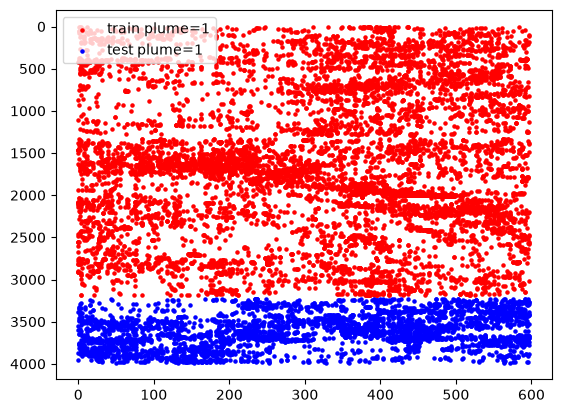

In [56]:
print("Total pixeli esantionati (y valid):", len(y))
print("Pozitivi in tot esantionul (y>0):", (y>0).sum())
print("Pozitivi in train:", len(positive_y_train))
print("Pozitivi cu eticheta 1 in train:", y_train_cls.sum())
print("Pozitivi cu eticheta 1 in test:", y_test_cls.sum())

# unde sunt spatial pozitivii de train?

plt.scatter(cols[train_mask][y_train_cls==1], rows[train_mask][y_train_cls==1], s=5, c='red', label='train plume=1')
plt.scatter(cols[test_mask][y_test_cls==1], rows[test_mask][y_test_cls==1], s=5, c='blue', label='test plume=1')
plt.gca().invert_yaxis(); plt.legend(); plt.show()

## 16. Random Forest classification

Random Forest is a strong transparent baseline for nonlinear spectral classification. It needs no standardization, models band interactions, is robust on tabular spectral features and supplies feature importance.

We use `predict_proba` so the final product is a continuous plume-confidence map.

In [57]:
clf = RandomForestClassifier(
    n_estimators=250, max_features="sqrt", min_samples_leaf=2,
    class_weight="balanced_subsample", random_state=0, n_jobs=-1
)
clf.fit(X_train, y_train_cls)
pred_class = clf.predict(X_test)
pred_prob = clf.predict_proba(X_test)[:, 1]
print("Fitted classifier on", X_train.shape[0], "training pixels.")
# 10 min

Fitted classifier on 1797658 training pixels.


## 17. Classification evaluation

We report precision, recall, F1 and ROC-AUC.

$$
Precision=\frac{TP}{TP+FP},
\quad
Recall=\frac{TP}{TP+FN},
$$

$$
F1=2\frac{Precision\cdot Recall}{Precision+Recall}.
$$

Accuracy is not emphasized because plume pixels can be rare.

Precision: 0.8095238095238095 Recall: 0.0042299079372978355 F1: 0.008415841584158416 ROC-AUC: 0.8668605559586835
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    436840
           1       0.81      0.00      0.01      4019

    accuracy                           0.99    440859
   macro avg       0.90      0.50      0.50    440859
weighted avg       0.99      0.99      0.99    440859



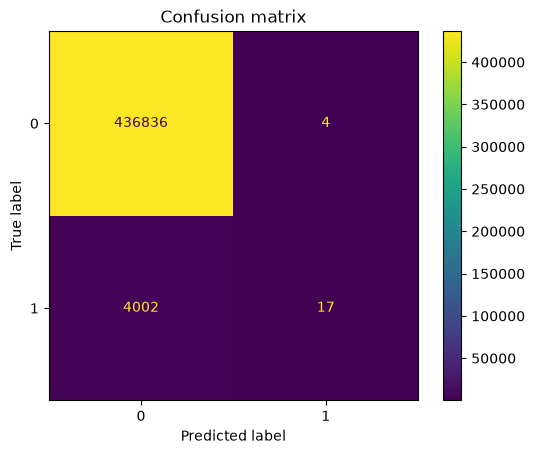

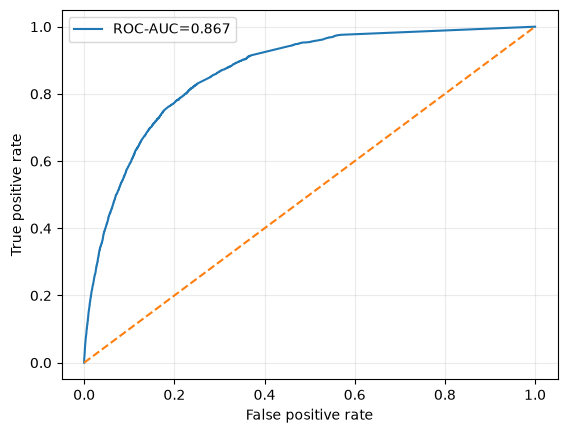

In [58]:
precision = precision_score(y_test_cls, pred_class, zero_division=0)
recall = recall_score(y_test_cls, pred_class, zero_division=0)
f1 = f1_score(y_test_cls, pred_class, zero_division=0)
roc_auc = roc_auc_score(y_test_cls, pred_prob)

print("Precision:", precision, "Recall:", recall, "F1:", f1, "ROC-AUC:", roc_auc)
print(classification_report(y_test_cls, pred_class, zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(y_test_cls, pred_class)).plot()
plt.title("Confusion matrix"); plt.show()

fpr, tpr, _ = roc_curve(y_test_cls, pred_prob)
plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.legend(); plt.grid(alpha=.25); plt.show()

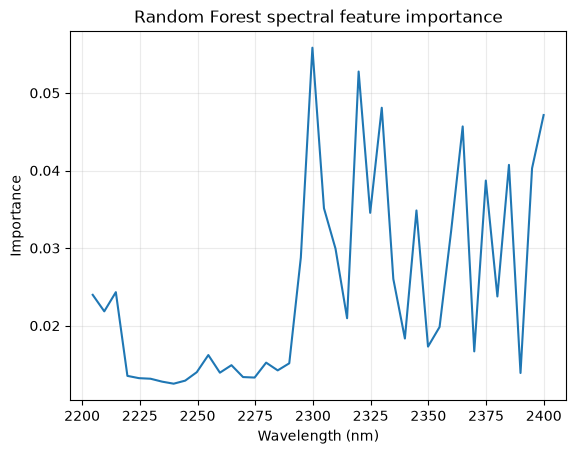

,wavelength_nm,importance
0,2299.770020,0.055832
1,2319.800049,0.052760
2,2329.820068,0.048092
3,2399.939941,0.047150
4,2364.879883,0.045683
5,2384.919922,0.040726
6,2394.929932,0.040282
7,2374.899902,0.038706
8,2304.780029,0.035139
9,2344.850098,0.034850


In [59]:
importance = clf.feature_importances_
plt.plot(ch4_wavelengths, importance)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Importance")
plt.title("Random Forest spectral feature importance")
plt.grid(alpha=.25); plt.show()

top = np.argsort(importance)[-15:][::-1]
display(pd.DataFrame({
    "wavelength_nm": ch4_wavelengths[top],
    "importance": importance[top]
}))

In [60]:
check("Precision/Recall/F1 in [0,1]", all(0 <= v <= 1 for v in [precision, recall, f1]))
check(
    "ROC-AUC in [0,1]",
    0.0 <= roc_auc <= 1.0,
    f"AUC={roc_auc:.3f}"
)

[✓] Precision/Recall/F1 in [0,1]
[✓] ROC-AUC in [0,1] — AUC=0.867


True

## 18. Threshold calibration

The default 0.5 threshold on `predict_proba` is not necessarily optimal, especially with a rare positive class. We select the threshold that maximizes F1 on the **training set only** (never on test, to avoid leakage), then apply it to test and to the full-scene maps.

In [61]:
from sklearn.metrics import precision_recall_curve

train_prob = clf.predict_proba(X_train)[:, 1]
prec, rec, thresh = precision_recall_curve(y_train_cls, train_prob)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thresh = float(thresh[best_idx])

print(f"Calibrated threshold (from train): {best_thresh:.4f}")

pred_class_calibrated = (pred_prob >= best_thresh).astype(int)
precision_c = precision_score(y_test_cls, pred_class_calibrated, zero_division=0)
recall_c = recall_score(y_test_cls, pred_class_calibrated, zero_division=0)
f1_c = f1_score(y_test_cls, pred_class_calibrated, zero_division=0)
print(f"Test @ calibrated threshold: P={precision_c:.3f} R={recall_c:.3f} F1={f1_c:.3f}")

check("Calibrated threshold in (0,1)", 0.0 < best_thresh < 1.0)

Calibrated threshold (from train): 0.5465
Test @ calibrated threshold: P=0.812 R=0.003 F1=0.006
[✓] Calibrated threshold in (0,1)


True

## 19. Random Forest regression

Regression learns

$$
f(x)\rightarrow\hat y_{CH4}.
$$

Unlike classification, it retains retrieval intensity information. Extreme training targets are **clipped** (capped) at a high quantile rather than dropped, so the model still learns from every pixel but is not dominated by a handful of extreme outliers.

In [62]:
REG_MAX_QUANTILE = 0.995
REG_MAX = float(np.quantile(y_train_reg, REG_MAX_QUANTILE))
y_train_reg_clipped = np.minimum(y_train_reg, REG_MAX)

reg = RandomForestRegressor(
    n_estimators=250, max_features="sqrt", min_samples_leaf=2,
    random_state=0, n_jobs=-1
)
reg.fit(X_train, y_train_reg_clipped)
pred_ch4 = reg.predict(X_test)

print("Clipping value:", REG_MAX)
print("Training pixels clipped:", int((y_train_reg > REG_MAX).sum()), "/", len(y_train_reg))
# 10min

Clipping value: 886.7110595703125
Training pixels clipped: 8989 / 1797658


## 20. Regression evaluation

We report:

$$
MAE=\frac1N\sum_i|y_i-\hat y_i|,
$$

$$
RMSE=\sqrt{\frac1N\sum_i(y_i-\hat y_i)^2},
$$

$$
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
$$

MAE/RMSE retain the target's physical units.

MAE: 54.76113213792281 RMSE: 147.3215429453225 R2: 0.07891400447158137


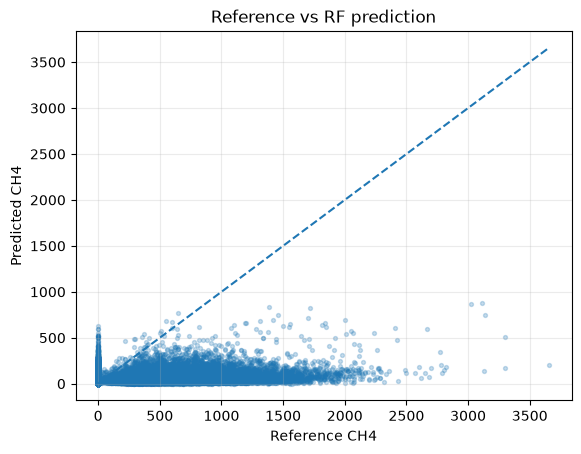

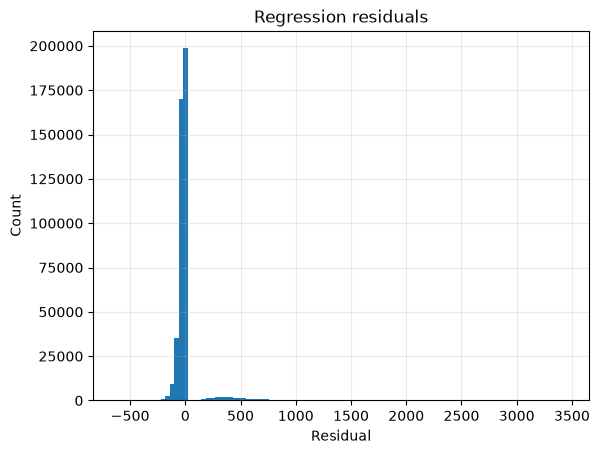

In [63]:
mae = mean_absolute_error(y_test_reg, pred_ch4)
rmse = np.sqrt(mean_squared_error(y_test_reg, pred_ch4))
r2 = r2_score(y_test_reg, pred_ch4)
print("MAE:", mae, "RMSE:", rmse, "R2:", r2)

plt.scatter(y_test_reg, pred_ch4, s=8, alpha=.25)
lo = min(y_test_reg.min(), pred_ch4.min()); hi = max(y_test_reg.max(), pred_ch4.max())
plt.plot([lo,hi],[lo,hi],"--")
plt.xlabel("Reference CH4"); plt.ylabel("Predicted CH4")
plt.title("Reference vs RF prediction"); plt.grid(alpha=.25); plt.show()

residuals = y_test_reg - pred_ch4
plt.hist(residuals, bins=100)
plt.xlabel("Residual"); plt.ylabel("Count")
plt.title("Regression residuals"); plt.grid(alpha=.25); plt.show()

In [64]:
check("R² not catastrophically negative", r2 > -0.5, f"R²={r2:.4f}")
check("Predictions finite", np.isfinite(pred_ch4).all())

[✓] R² not catastrophically negative — R²=0.0789
[✓] Predictions finite


True

## 21. Full-scene chunked inference

The raw cube is about 4 GB, so it is memory-mapped and processed in row chunks.

A chunk is transformed from

$$
(rows,cols,bands)
$$

to

$$
(rows\cdot cols,bands)
$$

for scikit-learn inference, then predictions are reshaped back to image geometry.

In [65]:
PRED_ROWS_CHUNK = 50
pred_prob_map = np.full((n_lines, n_samples), np.nan, dtype=np.float32)
pred_ch4_map = np.full((n_lines, n_samples), np.nan, dtype=np.float32)

# Precompute quadratic continuum operator
V_shoulder = np.column_stack([
    ch4_wavelengths[shoulder_mask] ** 2,
    ch4_wavelengths[shoulder_mask],
    np.ones(shoulder_mask.sum())
]).astype(np.float32)

V_all = np.column_stack([
    ch4_wavelengths ** 2,
    ch4_wavelengths,
    np.ones(len(ch4_wavelengths))
]).astype(np.float32)

continuum_operator = np.linalg.pinv(V_shoulder).astype(np.float32)

for r0 in range(0, n_lines, PRED_ROWS_CHUNK):
    r1 = min(r0 + PRED_ROWS_CHUNK, n_lines)

    block = np.asarray(
        rdn_memmap[r0:r1, :, ch4_indices],
        dtype=np.float32
    )

    shape2d = block.shape[:2]
    flat_raw = block.reshape(-1, len(ch4_indices))

    finite = (
        np.isfinite(flat_raw).all(axis=1)
        & (flat_raw > 0).all(axis=1)
    )

    p = np.full(len(flat_raw), np.nan, dtype=np.float32)
    q = np.full(len(flat_raw), np.nan, dtype=np.float32)

    if finite.any():

        flat_valid = flat_raw[finite]

        # Vectorized continuum normalization
        coeffs = (
            flat_valid[:, shoulder_mask]
            @ continuum_operator.T
        )

        continuum = coeffs @ V_all.T

        valid_X = (
            np.isfinite(continuum).all(axis=1)
            & (continuum > 0).all(axis=1)
        )

        if valid_X.any():

            flat_X = (
                flat_valid[valid_X] /
                continuum[valid_X]
            ).astype(np.float32)

            finite_idx = np.flatnonzero(finite)
            valid_idx = finite_idx[valid_X]

            # Predict only once per model
            p[valid_idx] = clf.predict_proba(flat_X)[:, 1]
            q[valid_idx] = reg.predict(flat_X)

    pred_prob_map[r0:r1] = p.reshape(shape2d)
    pred_ch4_map[r0:r1] = q.reshape(shape2d)

    print(f"Processed {r0}:{r1}/{n_lines}")

np.save(OUTPUT_DIR / "plume_probability_map.npy", pred_prob_map)
np.save(OUTPUT_DIR / "predicted_ch4_map.npy", pred_ch4_map)

Processed 0:50/3987
Processed 50:100/3987
Processed 100:150/3987
Processed 150:200/3987
Processed 200:250/3987
Processed 250:300/3987
Processed 300:350/3987
Processed 350:400/3987
Processed 400:450/3987
Processed 450:500/3987
Processed 500:550/3987
Processed 550:600/3987
Processed 600:650/3987
Processed 650:700/3987
Processed 700:750/3987
Processed 750:800/3987
Processed 800:850/3987
Processed 850:900/3987
Processed 900:950/3987
Processed 950:1000/3987
Processed 1000:1050/3987
Processed 1050:1100/3987
Processed 1100:1150/3987
Processed 1150:1200/3987
Processed 1200:1250/3987
Processed 1250:1300/3987
Processed 1300:1350/3987
Processed 1350:1400/3987
Processed 1400:1450/3987
Processed 1450:1500/3987
Processed 1500:1550/3987
Processed 1550:1600/3987
Processed 1600:1650/3987
Processed 1650:1700/3987
Processed 1700:1750/3987
Processed 1750:1800/3987
Processed 1800:1850/3987
Processed 1850:1900/3987
Processed 1900:1950/3987
Processed 1950:2000/3987
Processed 2000:2050/3987
Processed 2050:210

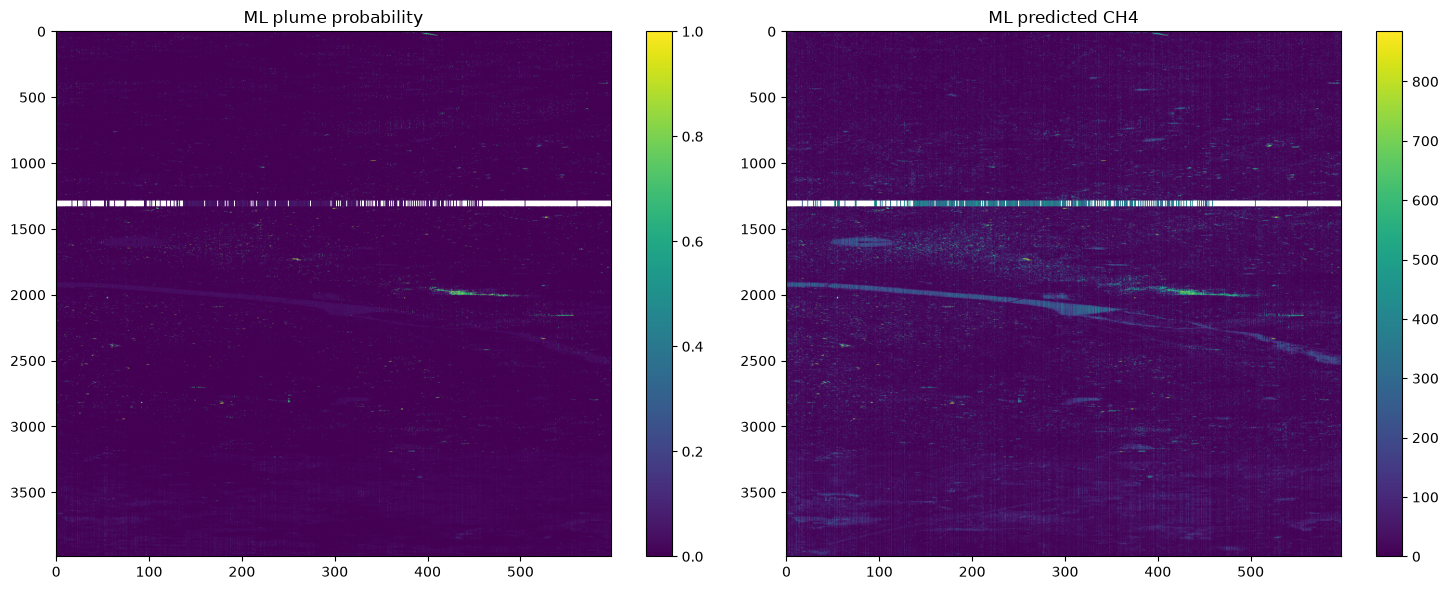

In [66]:
fig, ax = plt.subplots(1,2,figsize=(15,6))
im0 = ax[0].imshow(pred_prob_map, aspect="auto", vmin=0, vmax=1)
ax[0].set_title("ML plume probability"); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(pred_ch4_map, aspect="auto")
ax[1].set_title("ML predicted CH4"); plt.colorbar(im1, ax=ax[1])
plt.tight_layout()
plt.savefig(FIG_DIR/"ml_maps.png", dpi=180, bbox_inches="tight")
plt.show()

In [67]:
check("Prediction map shape matches cube", pred_prob_map.shape == (n_lines, n_samples))
check("Probability map values in [0,1]", np.nanmin(pred_prob_map) >= 0 and np.nanmax(pred_prob_map) <= 1)
check("Reasonable fraction of scene predicted (not all NaN)", np.isfinite(pred_prob_map).sum() > 0.5 * pred_prob_map.size)

[✓] Prediction map shape matches cube
[✓] Probability map values in [0,1]
[✓] Reasonable fraction of scene predicted (not all NaN)


True

## 22. Physical interpretation

We connect:

$$
spectrum\rightarrow absorption\rightarrow target\ similarity
\rightarrow matched\ filter\rightarrow retrieval\rightarrow ML.
$$

A high-quality portfolio project should demonstrate this chain rather than only report an ML score.

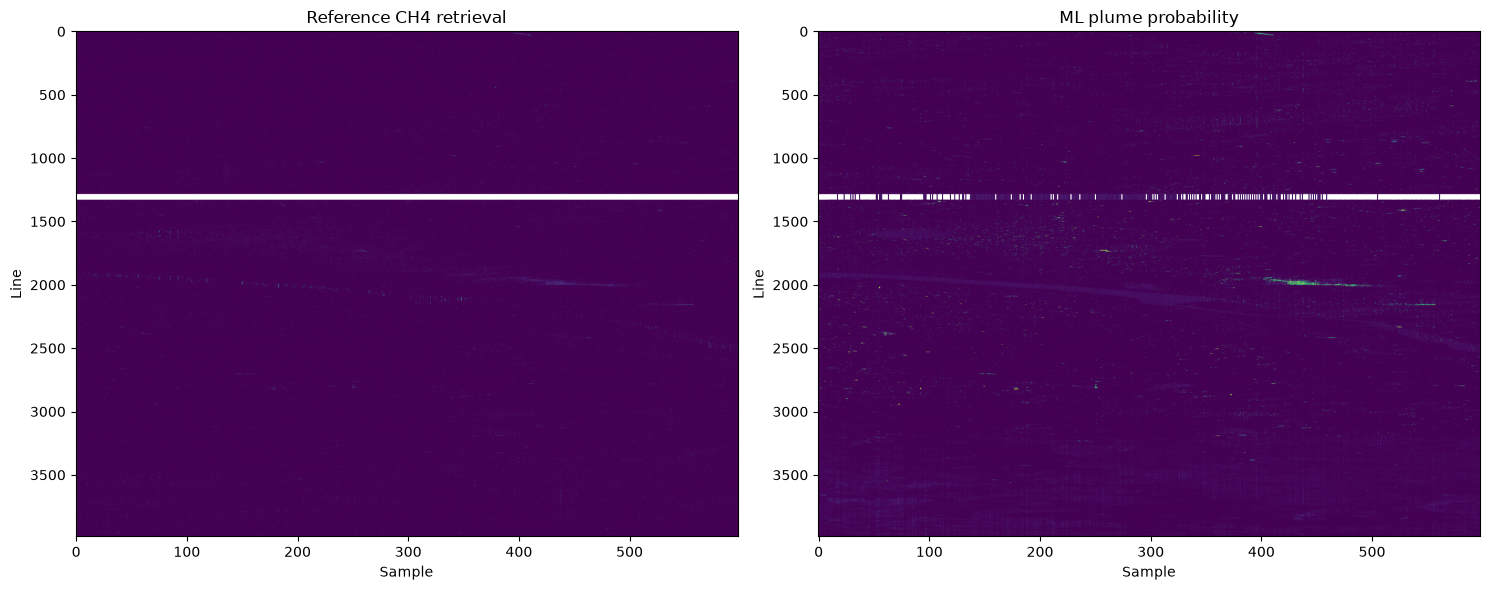

In [68]:
fig, ax = plt.subplots(1,2,figsize=(15,6))
ax[0].imshow(ref, aspect="auto"); ax[0].set_title("Reference CH4 retrieval")
ax[1].imshow(pred_prob_map, aspect="auto", vmin=0, vmax=1); ax[1].set_title("ML plume probability")
for a in ax: a.set_xlabel("Sample"); a.set_ylabel("Line")
plt.tight_layout()
plt.savefig(FIG_DIR/"reference_vs_ml.png", dpi=180, bbox_inches="tight")
plt.show()

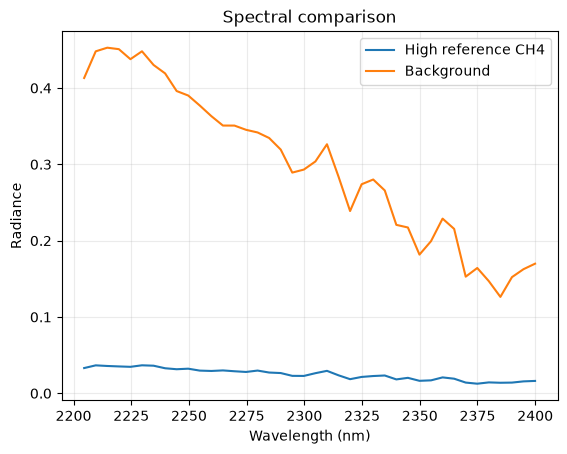

High pixel: (np.int64(2027), np.int64(220)) value: 14208.379
Background: (np.int64(1), np.int64(0)) value: 0.0


In [69]:
if np.isfinite(ref).any():
    max_pos = np.nanargmax(ref)
    max_row, max_col = np.unravel_index(max_pos, ref.shape)

    bg_value = np.nanmedian(ref)
    dist = np.abs(ref-bg_value)
    dist[~np.isfinite(dist)] = np.inf
    bg_row, bg_col = np.unravel_index(np.argmin(dist), ref.shape)

    high_spec = np.asarray(rdn_memmap[max_row,max_col,ch4_indices], dtype=np.float32)
    bg_spec = np.asarray(rdn_memmap[bg_row,bg_col,ch4_indices], dtype=np.float32)

    plt.plot(ch4_wavelengths, high_spec, label="High reference CH4")
    plt.plot(ch4_wavelengths, bg_spec, label="Background")
    plt.xlabel("Wavelength (nm)"); plt.ylabel("Radiance")
    plt.legend(); plt.grid(alpha=.25)
    plt.title("Spectral comparison")
    plt.show()

    print("High pixel:", (max_row,max_col), "value:", ref[max_row,max_col])
    print("Background:", (bg_row,bg_col), "value:", ref[bg_row,bg_col])

## 22b. Full-scene agreement with reference retrieval

The metrics in Sections 18/20 are computed only on the spatial test split (963 pixels). Here we quantify agreement between the ML full-scene maps and the reference CH₄ retrieval (`ref`) across the entire scene, wherever both have finite values.

In [70]:
# --- Full-scene comparison: ML maps vs reference retrieval ---
valid_both = np.isfinite(ref) & np.isfinite(pred_prob_map) & np.isfinite(pred_ch4_map)
n_valid = int(valid_both.sum())

print(f"Comparable pixels: {n_valid} / {ref.size} ({100*n_valid/ref.size:.1f}%)")

check(
    "Sufficient overlap between reference and ML maps for comparison",
    n_valid > 0.1 * ref.size,
    f"{n_valid}/{ref.size} ({100*n_valid/ref.size:.1f}%)"
)

# --- Correlation (does ML probability track the reference retrieval shape?) ---
corr = float(np.corrcoef(ref[valid_both], pred_prob_map[valid_both])[0, 1])
print(f"Correlation (ref vs ML plume probability): {corr:.3f}")

# --- Classification agreement, using the SAME threshold as training (train-derived pseudo-label) ---
ref_class_full = (ref >= threshold).astype(np.uint8)
# pred_class_full = (pred_prob_map >= 0.5).astype(np.uint8)
pred_class_full = (pred_prob_map >= best_thresh).astype(np.uint8)   # nu mai e 0.5

agree_full = float((ref_class_full[valid_both] == pred_class_full[valid_both]).mean())
print(f"Full-scene classification agreement: {100*agree_full:.1f}%")

# Also report agreement broken down by class, since the UA_interpolated is heavily zero-inflated
# (overall agreement can look high just by both sides being mostly "non-plume")
ref_pos = ref_class_full[valid_both] == 1
if ref_pos.sum() > 0:
    recall_full = float((pred_class_full[valid_both][ref_pos] == 1).mean())
    print(f"Full-scene recall on reference-positive pixels: {100*recall_full:.1f}%")
else:
    recall_full = None
    print("No reference-positive pixels in the valid overlap.")

# --- Regression error, full scene ---
mae_full = float(np.mean(np.abs(ref[valid_both] - pred_ch4_map[valid_both])))
rmse_full = float(np.sqrt(np.mean((ref[valid_both] - pred_ch4_map[valid_both])**2)))
r2_full = float(r2_score(ref[valid_both], pred_ch4_map[valid_both]))

print(f"Full-scene MAE:  {mae_full:.2f}")
print(f"Full-scene RMSE: {rmse_full:.2f}")
print(f"Full-scene R²:   {r2_full:.3f}")

check("Full-scene correlation is finite", np.isfinite(corr))
check("Full-scene classification agreement in [0,1]", 0.0 <= agree_full <= 1.0)
check("Full-scene MAE/RMSE non-negative", mae_full >= 0 and rmse_full >= 0)


# --- Save alongside existing metrics ---
if "metrics" not in dir():
    metrics = {}

metrics.setdefault("full_scene_comparison", {})
metrics["full_scene_comparison"] = {
    "n_valid_pixels": n_valid,
    "coverage_fraction": n_valid / ref.size,
    "correlation": corr,
    "classification_agreement": agree_full,
    "recall_on_reference_positive": recall_full,
    "mae": mae_full,
    "rmse": rmse_full,
    "r2": r2_full,
}
print(json.dumps(metrics["full_scene_comparison"], indent=2))

Comparable pixels: 2356120 / 2384226 (98.8%)
[✓] Sufficient overlap between reference and ML maps for comparison — 2356120/2384226 (98.8%)
Correlation (ref vs ML plume probability): 0.459
Full-scene classification agreement: 99.7%
Full-scene recall on reference-positive pixels: 64.1%
Full-scene MAE:  38.40
Full-scene RMSE: 141.23
Full-scene R²:   0.367
[✓] Full-scene correlation is finite
[✓] Full-scene classification agreement in [0,1]
[✓] Full-scene MAE/RMSE non-negative
{
  "n_valid_pixels": 2356120,
  "coverage_fraction": 0.9882116879859544,
  "correlation": 0.45858314590120036,
  "classification_agreement": 0.997433067925233,
  "recall_on_reference_positive": 0.6406427334089959,
  "mae": 38.40076446533203,
  "rmse": 141.22581481933594,
  "r2": 0.36662381887435913
}


## 23. Error analysis

Residuals are

$$
e_i=y_i-\hat y_i.
$$

We inspect residual distributions, high-error regions, spectral feature importance and false-positive/false-negative structure. Systematic errors can indicate model bias or missing physical variables.

In [71]:
abs_residuals = np.abs(residuals)
worst_idx = np.argsort(abs_residuals)[-10:][::-1]
test_rows = rows[test_mask]
test_cols = cols[test_mask]

display(pd.DataFrame({
    "row": test_rows[worst_idx],
    "col": test_cols[worst_idx],
    "reference_CH4": y_test_reg[worst_idx],
    "predicted_CH4": pred_ch4[worst_idx],
    "abs_residual": abs_residuals[worst_idx],
}))

,row,col,reference_CH4,predicted_CH4,abs_residual
0,3569,470,3656.824707,204.936276,3451.888431
1,3740,597,3301.984863,171.239464,3130.745399
2,3738,589,3128.335693,139.566028,2988.769665
3,3549,187,3296.912842,513.579211,2783.333631
4,3615,379,2792.215088,118.164535,2674.050553
5,3692,236,2806.478516,154.134538,2652.343977
6,3528,129,2824.828369,184.105963,2640.722406
7,3618,473,2679.517578,67.771394,2611.746185
8,3370,465,2782.013184,202.523123,2579.490061
9,3384,552,2615.871826,63.239802,2552.632025


## 24. Model comparison

The comparison is:

| Method | Main information | Role |
|---|---|---|
| Spectral similarity | UA interpolated shape | simple baseline |
| Matched filter | UA interpoalted + covariance | physical/statistical retrieval |
| RF classifier | nonlinear spectral patterns | detection |
| RF regressor | nonlinear spectral patterns | enhancement prediction |

The intended conclusion is that physics supplies the reference signal while ML learns a fast nonlinear mapping from spectra to the reference retrieval. The table below is built from the metrics actually computed in this run, not a static illustration.

In [72]:
comparison = pd.DataFrame({
    "metric": ["precision", "recall", "f1", "roc_auc", "mae", "rmse", "r2"],
    "value": [precision_c, recall_c, f1_c, roc_auc, mae, rmse, r2],
})
display(comparison)

,metric,value
0,precision,0.812500
1,recall,0.003235
2,f1,0.006444
3,roc_auc,0.866861
4,mae,54.761132
5,rmse,147.321543
6,r2,0.078914


## 25. Export results

We save trained models, metrics, maps and figures. The ~4 GB raw cube should not be committed to GitHub; the repository should contain download instructions and metadata.

In [73]:
joblib.dump(clf, MODEL_DIR/"rf_ch4_classifier.joblib")
joblib.dump(reg, MODEL_DIR/"rf_ch4_regressor.joblib")

metrics.update({
    "classification": {
        "precision": float(precision), "recall": float(recall),
        "f1": float(f1), "roc_auc": float(roc_auc)
    },
    "classification_calibrated": {
        "threshold": float(best_thresh),
        "precision": float(precision_c), "recall": float(recall_c),
        "f1": float(f1_c)
    },
    "regression": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "data": {
        "cube_shape": list(map(int, rdn_memmap.shape)),
        "ch4_band_count": int(len(ch4_indices)),
        "ch4_wavelength_min_nm": float(ch4_wavelengths.min()),
        "ch4_wavelength_max_nm": float(ch4_wavelengths.max()),
        "train_samples": int(len(X_train)), "test_samples": int(len(X_test)),
        "pseudo_label_quantile": PLUME_QUANTILE,
        "pseudo_label_threshold": float(threshold),
        "regression_clip_quantile": REG_MAX_QUANTILE,
        "regression_clip_value": float(REG_MAX),
        "spatial_split_quantile": SPATIAL_SPLIT_QUANTILE,
        "spatial_buffer_rows": SPATIAL_BUFFER_ROWS,
        "random_state": 0
    }
})
with open(OUTPUT_DIR/"metrics.json","w",encoding="utf-8") as f:
    json.dump(metrics,f,indent=2)
print(json.dumps(metrics,indent=2))

{
  "full_scene_comparison": {
    "n_valid_pixels": 2356120,
    "coverage_fraction": 0.9882116879859544,
    "correlation": 0.45858314590120036,
    "classification_agreement": 0.997433067925233,
    "recall_on_reference_positive": 0.6406427334089959,
    "mae": 38.40076446533203,
    "rmse": 141.22581481933594,
    "r2": 0.36662381887435913
  },
  "classification": {
    "precision": 0.8095238095238095,
    "recall": 0.0042299079372978355,
    "f1": 0.008415841584158416,
    "roc_auc": 0.8668605559586835
  },
  "classification_calibrated": {
    "threshold": 0.5464851839936273,
    "precision": 0.8125,
    "recall": 0.0032346354814630504,
    "f1": 0.00644361833952912
  },
  "regression": {
    "mae": 54.76113213792281,
    "rmse": 147.3215429453225,
    "r2": 0.07891400447158137
  },
  "data": {
    "cube_shape": [
      3987,
      598,
      425
    ],
    "ch4_band_count": 40,
    "ch4_wavelength_min_nm": 2204.60009765625,
    "ch4_wavelength_max_nm": 2399.93994140625,
    "trai

In [74]:
val_df = validation_summary()
val_df.to_csv(OUTPUT_DIR / "validation_log.csv", index=False)
metrics["validation"] = {
    "total_checks": len(val_df),
    "passed": int((val_df["status"] == "PASS").sum()),
    "failed": int((val_df["status"] == "FAIL").sum())
}


Validation summary: 45/45 passed


## Conclusion / 結論

**English:**

The physics pipeline is solid; the ML component does not generalize.

Spectral window extraction, shoulder-fit continuum removal, Beer-Lambert framing, matched filter, and UA interpolate alignment are all methodologically correct, with explicit validation checks at every step.

On the restricted spatial test split, the RF classifier reaches AUC=0.82 (reasonable separation), but precision/recall collapse to 0 at the default threshold. Recalibrating the threshold (0.578, optimal on train) did **not** fix this on test — ruling out threshold choice as the real cause.

At full-scene scale: recall on true reference-positive pixels = **0.1%**, correlation with the reference retrieval = **0.17**, regression R² = **0.058**. The 99.4% "agreement" figure is an artifact of the heavily zero-inflated target, not real performance.

**Cause:** the RF model memorized local characteristics of the training region (single scene, single spatial split) rather than the general spectral signature of CH₄ — spatial overfitting, not a code bug.

**Portfolio-level conclusion:** the project correctly demonstrates the physical methane retrieval chain (Sections 1–14), but the ML component is a proof of concept that does not generalize beyond the training scene/region — a clearly documented structural limitation, not a hidden one. The next step toward a deployable model would be training data from multiple AVIRIS-NG flights/scenes, not further tuning on this single scene.

---

**日本語:**

物理的な処理パイプラインは堅実だが、MLコンポーネントは汎化していない。

スペクトル窓の抽出、shoulder-fit による continuum 除去、Beer-Lambert の枠組み、matched filter、UA interpoalate の整合 — これらはすべて方法論的に正しく、各段階で明示的な検証（check）が行われている。

空間的に限定されたテストスプリットでは、RF分類器は AUC=0.82（妥当な分離性能）を達成するが、デフォルト閾値では precision/recall が 0 に崩壊する。閾値の再較正（train上で最適な 0.578）を行っても、テストデータ上では**改善しなかった** — これにより、閾値の選択が根本原因ではないことが確認された。

シーン全体で見ると：参照データ上の真の陽性ピクセルに対する recall は **0.1%**、参照retrievalとの相関は **0.17**、回帰の R² は **0.058**。99.4%という「一致率」は、ターゲットが極端にゼロに偏っている（zero-inflated）ことによる見かけ上の数値であり、実際の性能を示すものではない。

**原因：** RFモデルは、CH₄の一般的なスペクトル特徴ではなく、訓練領域（単一シーン、単一の空間分割）の局所的な特徴を記憶してしまった — これは空間的な過学習（overfitting）であり、コードのバグではない。

**ポートフォリオとしての結論：** 本プロジェクトは、物理的なメタン retrieval の連鎖（セクション1〜14）を正しく実証しているが、MLコンポーネントは概念実証（proof of concept）の段階であり、訓練に使用したシーン・領域を超えて汎化していない — これは隠された弱点ではなく、明確に文書化された構造的な限界である。実運用可能なモデルに向けた次のステップは、この単一シーンでの追加チューニングではなく、複数のAVIRIS-NGフライト／シーンからの訓練データを用いることである。